# Exploración del Dataset

In [2]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pyarrow

Exploración de los diferentes grupos de clasificación que se analizarán:

* A. Major merger + AGN activo post merger.
* B. Major merger sin AGN activo post merger (Ver si son pocas muestras).
* C. Sin merger con AGN activo.
* D. Sin merger sin AGN.
* E. Major merger para simu NoAGN.

## Sobre la simu RefL0100N1504

In [18]:
# Cargamos los datos de la tabla de galaxias centrales
data_centrales = pl.read_csv('data/tracks_centrales_snap28.csv')

# Cargamos los datos de las fusines
data_fusiones = pl.read_csv('data/historial_merger_centrales_snap28.csv')

In [19]:
# Información hisórica del desarrollo de las galaxias centrales
data_centrales

GalaxyID,SnapNum,Redshift,Stars_Mass,Stars_KineticEnergy,Stars_Spin_x,Stars_Spin_y,Stars_Spin_z,SF_Mass,SF_Oxygen,SF_Hydrogen,SF_MassWeightedTemperature,SF_KineticEnergy,SF_ThermalEnergy,SF_TotalEnergy,SF_Spin_x,SF_Spin_y,SF_Spin_z,BlackHoleMass,BlackHoleMassAccretionRate,SubHaloGalaxyID,RootGalaxyID
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64
8646393,12,3.0165045,1.8160373e8,8.9158e11,-82.79168,-55.60781,-12.126945,9.0397677e8,0.001334,0.7472645,12797.512,3.7069e12,2.2132e11,-2.7809e13,-47.896557,-75.066986,-49.20585,149624.95,1.0145e-10,8646393,8646377
8646392,13,2.4784133,4.0484758e8,1.6541e12,-27.682028,55.63432,90.33163,1.0362e9,0.002073,0.745057,11154.858,3.3986e12,2.2240e11,-3.7311e13,-28.94864,177.06952,169.04736,149628.08,2.2226e-9,8646392,8646377
8646391,14,2.237037,6.7043725e8,4.5140e12,-441.0218,-108.29286,311.47806,2.2858e9,0.002123,0.7448175,11240.432,1.2060e13,4.9555e11,-1.1021e14,-98.34161,193.81024,268.26166,149650.48,7.4560e-9,8646391,8646377
8646390,15,2.0124102,1.0876e9,6.8919e12,-590.81024,-142.63943,503.46362,2.9391e9,0.003144,0.7411371,12233.35,2.1326e13,6.9291e11,-1.5328e14,-486.67294,-134.645,331.67664,149653.77,7.1106e-9,8646390,8646377
8646389,16,1.7369658,1.7818e9,8.2777e12,-443.32837,-363.82037,186.82681,3.5689e9,0.004233,0.7362861,9807.323,1.7867e13,6.7435e11,-2.1800e14,-560.2389,-350.9041,29.797092,298193.6,2.2962e-8,8646389,8646377
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
21986365,24,0.365669,8.0355e11,1.3398e17,-8157.2715,-4815.6025,-7921.742,1.5845e10,0.009007,0.7135603,14842.011,1.4543e15,4.3683e12,-1.8960e16,18130.81,-38427.527,-3099.3567,1.0961e9,0.00445,21986365,21986361
21986364,25,0.270901,9.1478e11,2.1425e17,-3263.4863,-13905.607,-23574.283,1.4140e10,0.009128,0.7106501,15650.902,2.7811e15,4.1468e12,-1.6325e16,13426.726,-36767.79,-18871.074,1.1888e9,0.012013,21986364,21986361
21986363,26,0.18271,1.0332e12,1.9705e17,-2159.21,-12064.919,-21040.172,1.0932e10,0.00931,0.711415,13835.004,1.2363e15,2.7834e12,-1.4122e16,12981.541,-47848.95,-39117.74,8.605493e8,0.000002,21986363,21986361


In [20]:
# Le agregamos una columna de tiempo a la tabla de galaxias centrales usando el diccionario de snaps a tiempos
# Diccionario para mapear los snaps a tiempos aproximados en Gyr
snap_to_time = {12:11.68, 13:11.17, 14:10.87, 15:10.54, 16:10.05, 17:9.49, 18:8.86, 19: 7.96,
                20: 7.35, 21:6.69, 22: 5.98, 23: 5.22, 24: 4.12, 25: 3.24, 26: 2.32, 27: 1.35, 28: 0}
map_df = pl.DataFrame({
    "SnapNum": list(snap_to_time.keys()),
    "LookbackTime(Gyr)": list(snap_to_time.values())
})

data_centrales = data_centrales.join(map_df, on="SnapNum", how="left")

In [21]:
data_centrales

GalaxyID,SnapNum,Redshift,Stars_Mass,Stars_KineticEnergy,Stars_Spin_x,Stars_Spin_y,Stars_Spin_z,SF_Mass,SF_Oxygen,SF_Hydrogen,SF_MassWeightedTemperature,SF_KineticEnergy,SF_ThermalEnergy,SF_TotalEnergy,SF_Spin_x,SF_Spin_y,SF_Spin_z,BlackHoleMass,BlackHoleMassAccretionRate,SubHaloGalaxyID,RootGalaxyID,LookbackTime(Gyr)
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64
8646393,12,3.0165045,1.8160373e8,8.9158e11,-82.79168,-55.60781,-12.126945,9.0397677e8,0.001334,0.7472645,12797.512,3.7069e12,2.2132e11,-2.7809e13,-47.896557,-75.066986,-49.20585,149624.95,1.0145e-10,8646393,8646377,11.68
8646392,13,2.4784133,4.0484758e8,1.6541e12,-27.682028,55.63432,90.33163,1.0362e9,0.002073,0.745057,11154.858,3.3986e12,2.2240e11,-3.7311e13,-28.94864,177.06952,169.04736,149628.08,2.2226e-9,8646392,8646377,11.17
8646391,14,2.237037,6.7043725e8,4.5140e12,-441.0218,-108.29286,311.47806,2.2858e9,0.002123,0.7448175,11240.432,1.2060e13,4.9555e11,-1.1021e14,-98.34161,193.81024,268.26166,149650.48,7.4560e-9,8646391,8646377,10.87
8646390,15,2.0124102,1.0876e9,6.8919e12,-590.81024,-142.63943,503.46362,2.9391e9,0.003144,0.7411371,12233.35,2.1326e13,6.9291e11,-1.5328e14,-486.67294,-134.645,331.67664,149653.77,7.1106e-9,8646390,8646377,10.54
8646389,16,1.7369658,1.7818e9,8.2777e12,-443.32837,-363.82037,186.82681,3.5689e9,0.004233,0.7362861,9807.323,1.7867e13,6.7435e11,-2.1800e14,-560.2389,-350.9041,29.797092,298193.6,2.2962e-8,8646389,8646377,10.05
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
21986365,24,0.365669,8.0355e11,1.3398e17,-8157.2715,-4815.6025,-7921.742,1.5845e10,0.009007,0.7135603,14842.011,1.4543e15,4.3683e12,-1.8960e16,18130.81,-38427.527,-3099.3567,1.0961e9,0.00445,21986365,21986361,4.12
21986364,25,0.270901,9.1478e11,2.1425e17,-3263.4863,-13905.607,-23574.283,1.4140e10,0.009128,0.7106501,15650.902,2.7811e15,4.1468e12,-1.6325e16,13426.726,-36767.79,-18871.074,1.1888e9,0.012013,21986364,21986361,3.24
21986363,26,0.18271,1.0332e12,1.9705e17,-2159.21,-12064.919,-21040.172,1.0932e10,0.00931,0.711415,13835.004,1.2363e15,2.7834e12,-1.4122e16,12981.541,-47848.95,-39117.74,8.605493e8,0.000002,21986363,21986361,2.32


In [22]:
# Historial de fusiones de las galaxias centrales
data_fusiones

GalaxyID,Snapshot,Lm
i64,i64,f64
8646377,3,1.0
8646377,4,1.0
8646377,5,1.0
8646377,6,1.0
8646377,7,1.0
…,…,…
21986361,24,1.001543
21986361,25,1.000458
21986361,26,1.041736


In [23]:
# Unimos las tablas para obtener una visión completa de la evolución de las galaxias centrales
new_data = data_centrales.join(data_fusiones, left_on=['RootGalaxyID','SnapNum'], right_on=['GalaxyID','Snapshot'], how='left')

new_data

GalaxyID,SnapNum,Redshift,Stars_Mass,Stars_KineticEnergy,Stars_Spin_x,Stars_Spin_y,Stars_Spin_z,SF_Mass,SF_Oxygen,SF_Hydrogen,SF_MassWeightedTemperature,SF_KineticEnergy,SF_ThermalEnergy,SF_TotalEnergy,SF_Spin_x,SF_Spin_y,SF_Spin_z,BlackHoleMass,BlackHoleMassAccretionRate,SubHaloGalaxyID,RootGalaxyID,LookbackTime(Gyr),Lm
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64
8646393,12,3.0165045,1.8160373e8,8.9158e11,-82.79168,-55.60781,-12.126945,9.0397677e8,0.001334,0.7472645,12797.512,3.7069e12,2.2132e11,-2.7809e13,-47.896557,-75.066986,-49.20585,149624.95,1.0145e-10,8646393,8646377,11.68,1.020797
8646392,13,2.4784133,4.0484758e8,1.6541e12,-27.682028,55.63432,90.33163,1.0362e9,0.002073,0.745057,11154.858,3.3986e12,2.2240e11,-3.7311e13,-28.94864,177.06952,169.04736,149628.08,2.2226e-9,8646392,8646377,11.17,1.208551
8646391,14,2.237037,6.7043725e8,4.5140e12,-441.0218,-108.29286,311.47806,2.2858e9,0.002123,0.7448175,11240.432,1.2060e13,4.9555e11,-1.1021e14,-98.34161,193.81024,268.26166,149650.48,7.4560e-9,8646391,8646377,10.87,1.002513
8646390,15,2.0124102,1.0876e9,6.8919e12,-590.81024,-142.63943,503.46362,2.9391e9,0.003144,0.7411371,12233.35,2.1326e13,6.9291e11,-1.5328e14,-486.67294,-134.645,331.67664,149653.77,7.1106e-9,8646390,8646377,10.54,1.0
8646389,16,1.7369658,1.7818e9,8.2777e12,-443.32837,-363.82037,186.82681,3.5689e9,0.004233,0.7362861,9807.323,1.7867e13,6.7435e11,-2.1800e14,-560.2389,-350.9041,29.797092,298193.6,2.2962e-8,8646389,8646377,10.05,1.004163
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
21986365,24,0.365669,8.0355e11,1.3398e17,-8157.2715,-4815.6025,-7921.742,1.5845e10,0.009007,0.7135603,14842.011,1.4543e15,4.3683e12,-1.8960e16,18130.81,-38427.527,-3099.3567,1.0961e9,0.00445,21986365,21986361,4.12,1.001543
21986364,25,0.270901,9.1478e11,2.1425e17,-3263.4863,-13905.607,-23574.283,1.4140e10,0.009128,0.7106501,15650.902,2.7811e15,4.1468e12,-1.6325e16,13426.726,-36767.79,-18871.074,1.1888e9,0.012013,21986364,21986361,3.24,1.000458
21986363,26,0.18271,1.0332e12,1.9705e17,-2159.21,-12064.919,-21040.172,1.0932e10,0.00931,0.711415,13835.004,1.2363e15,2.7834e12,-1.4122e16,12981.541,-47848.95,-39117.74,8.605493e8,0.000002,21986363,21986361,2.32,1.041736


In [24]:
# Trabajamos con galaxias que no hayan tenido en su historia fusiones mayores a un Lm mayor a 2.5.
# Me guardo el ID de las galaxias que cumplen esta condición para luego filtrar el dataset original

list_id = new_data.group_by('RootGalaxyID').agg(pl.max('Lm').alias('max')).filter(pl.col('max') < 2.5).select('RootGalaxyID')
#new_data.group_by('RootGalaxyID').agg(pl.max('Lm').alias('max')).filter(pl.col('max') < 2.5).select('RootGalaxyID')

mask_id = (pl.col('RootGalaxyID').is_in(list_id['RootGalaxyID']))

# Filtramos el dataset original para quedarnos solo con las galaxias que cumplen la condición
filtered_data = new_data.filter(mask_id)

/tmp/ipykernel_7009/1865654661.py:10: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  filtered_data = new_data.filter(mask_id)


In [25]:
# Calculamos variables adicionales para el análisis


filtered_data = filtered_data.with_columns(
    # Logaritmos
    pl.col('Stars_Mass').log10().alias('Log(Stars_Mass)'),
    pl.col('BlackHoleMass').log10().alias('Log(BlackHoleMass)'),
    
    # Norma de Stars_Spin (usando una expresión más limpia)
    (pl.col('Stars_Spin_x')**2 + pl.col('Stars_Spin_y')**2 + pl.col('Stars_Spin_z')**2)
    .sqrt().alias('Stars_Spin_Total'),
    
    # Norma de SF_Spin
    (pl.col('SF_Spin_x')**2 + pl.col('SF_Spin_y')**2 + pl.col('SF_Spin_z')**2)
    .sqrt().alias('SF_Spin_Total'),
    
    # Norma del Spin de gas SF y Stars
    ((pl.col('SF_Spin_x')+pl.col('Stars_Spin_x'))**2 + (pl.col('SF_Spin_y')+pl.col('Stars_Spin_y'))**2 + (pl.col('SF_Spin_z')+pl.col('Stars_Spin_z'))**2)
    .sqrt().alias('Total_Spin'),
    
    # Calculo de metalicidad.
    (12 + pl.col('SF_Oxygen').log10() - pl.col('SF_Hydrogen').log10()-np.log10(16)).alias('12+log(O/H)')
)

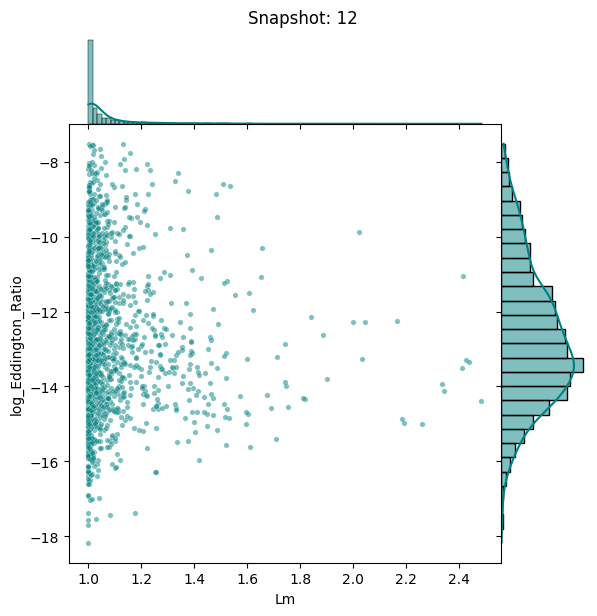

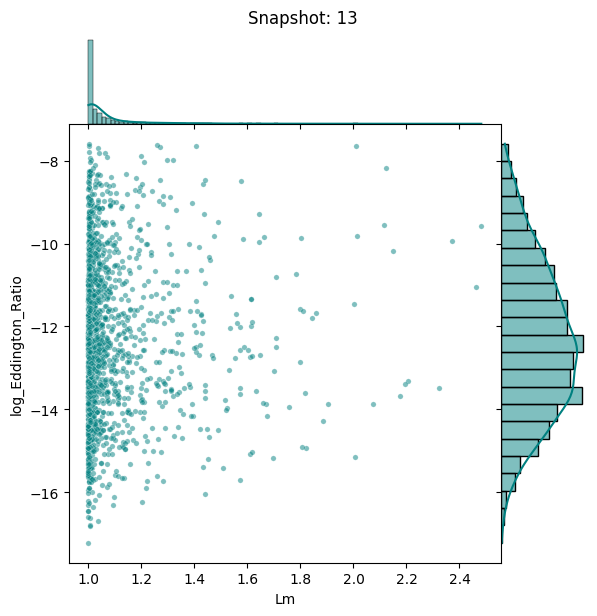

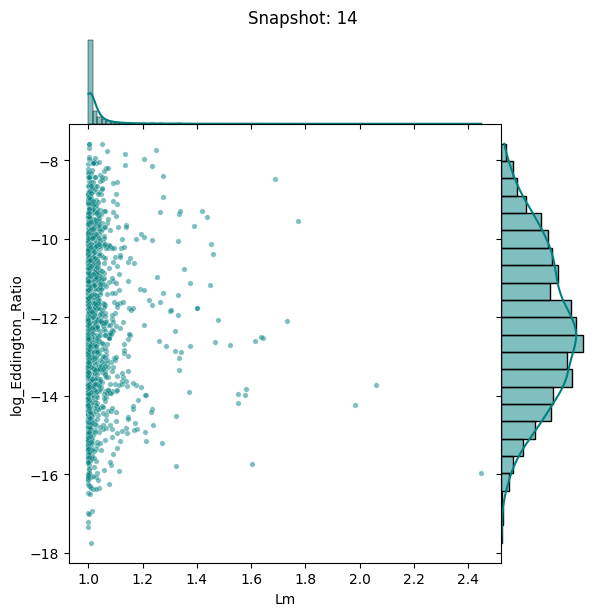

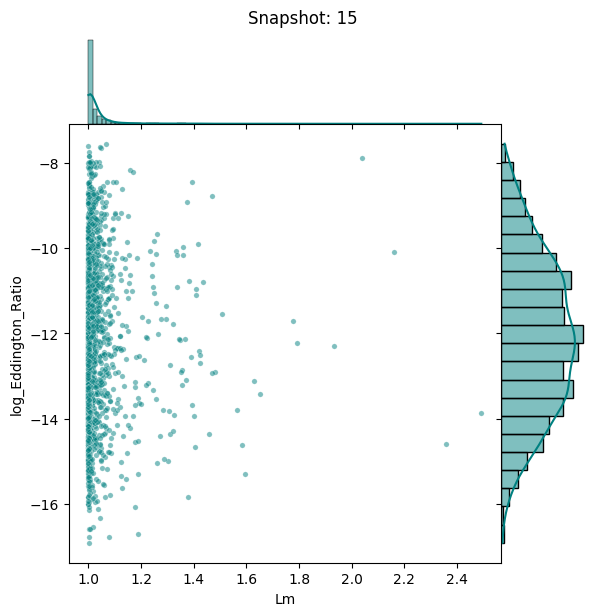

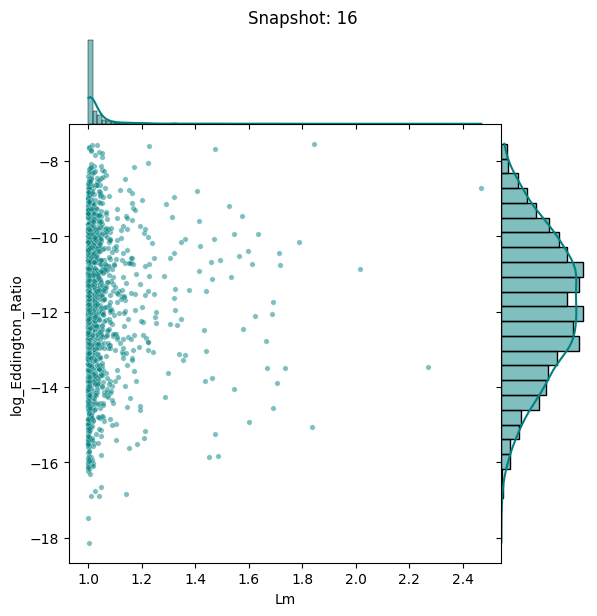

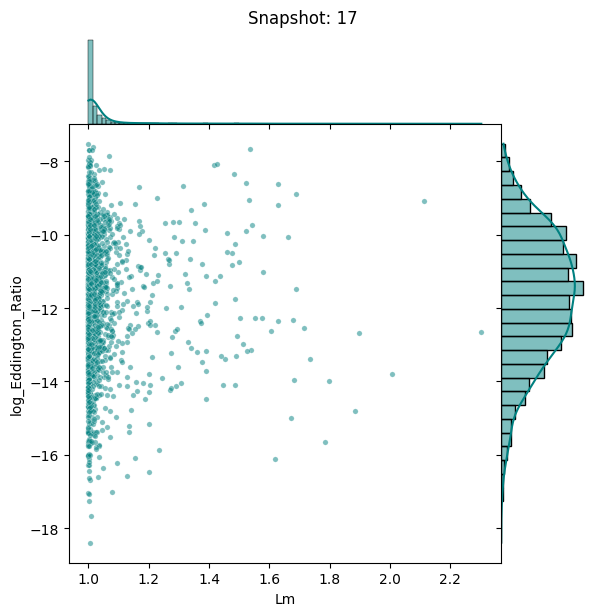

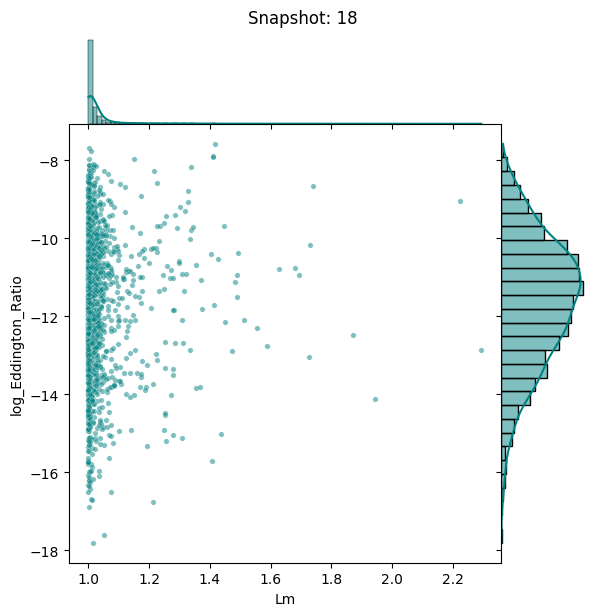

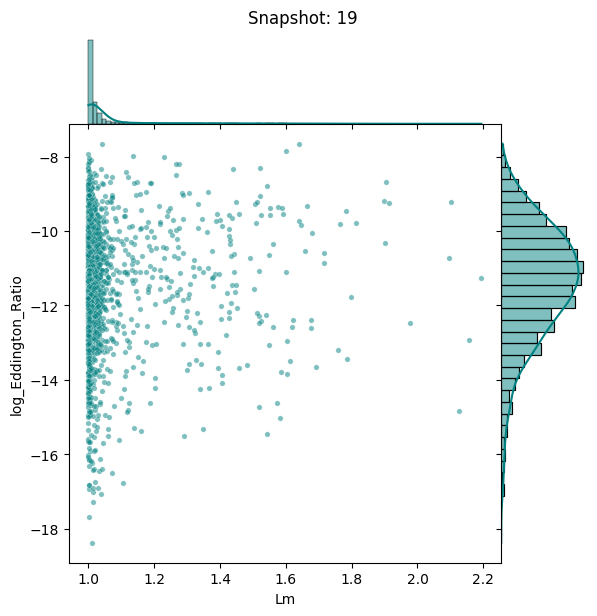

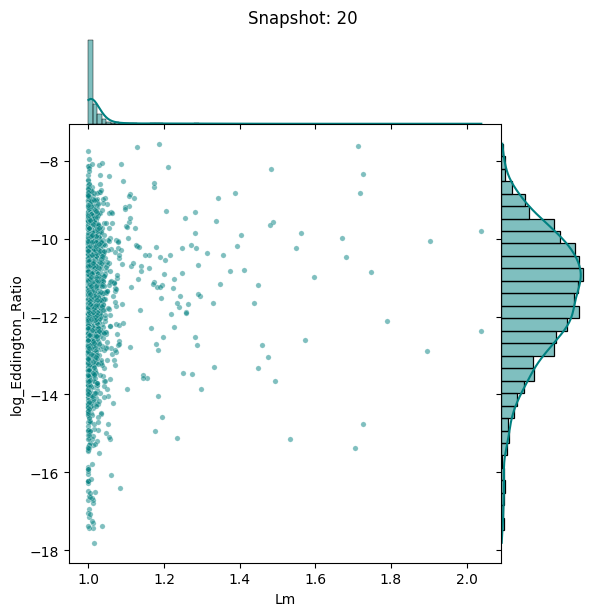

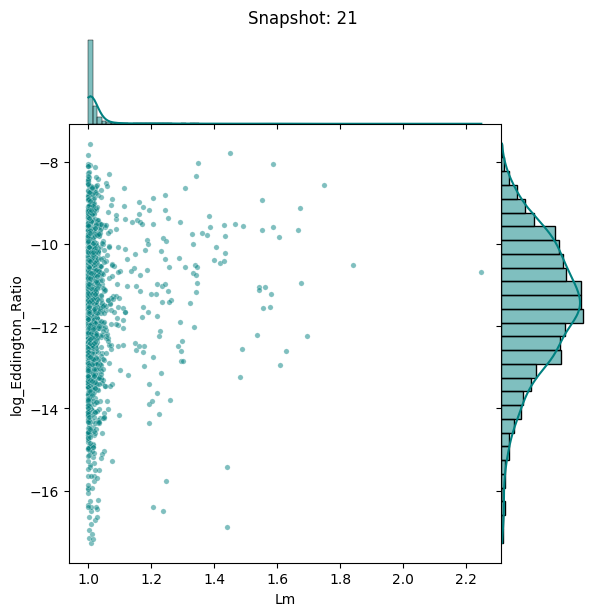

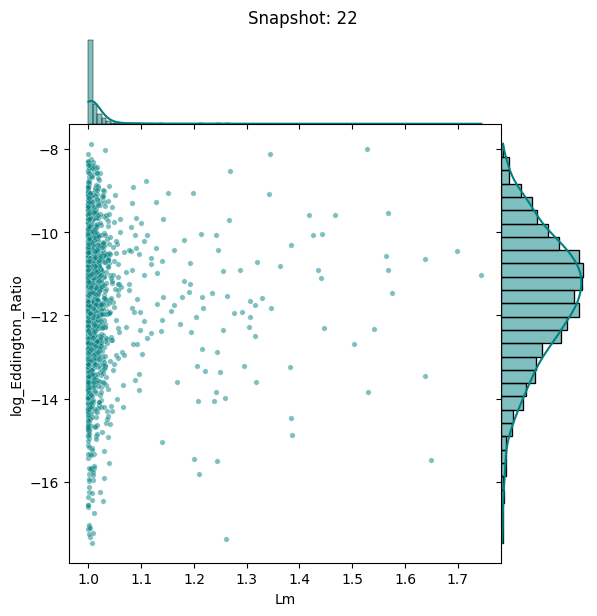

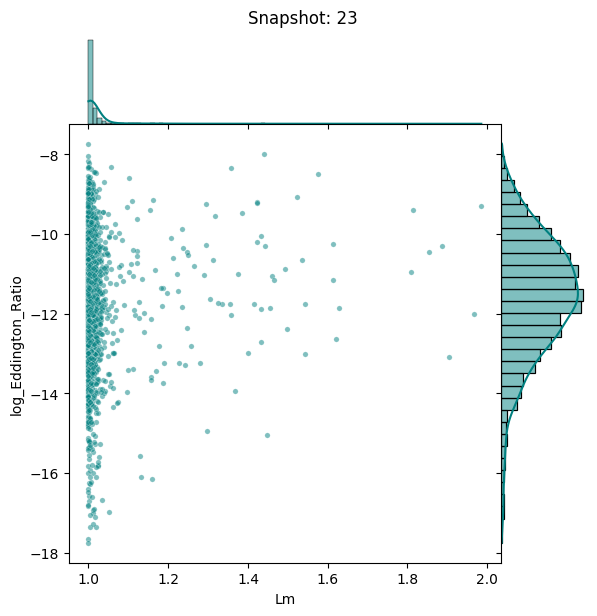

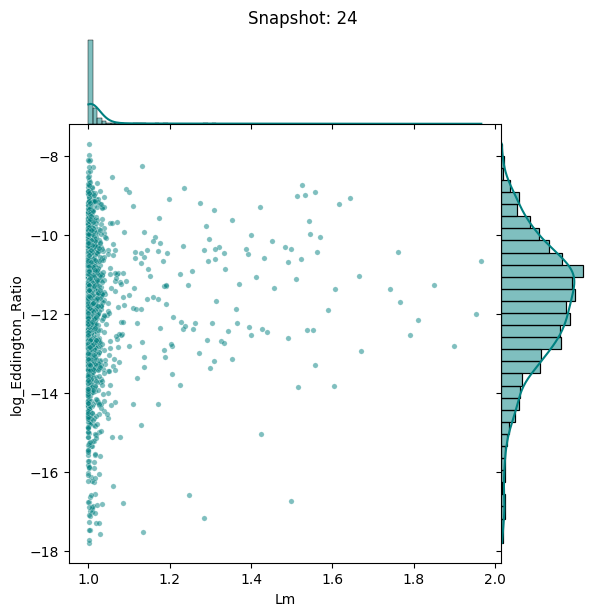

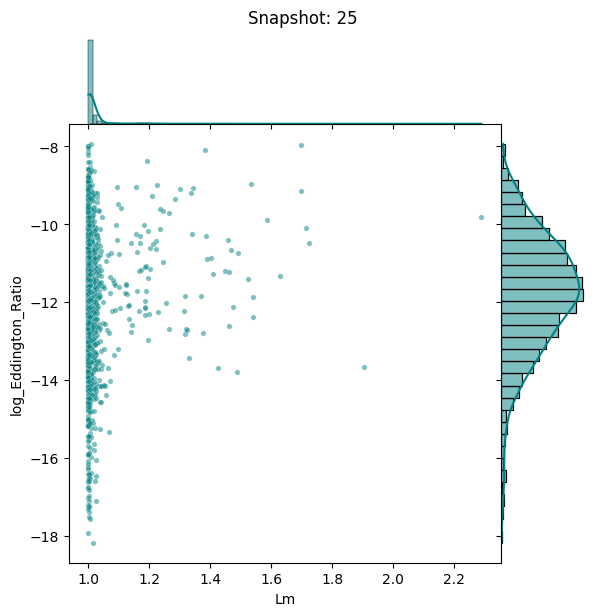

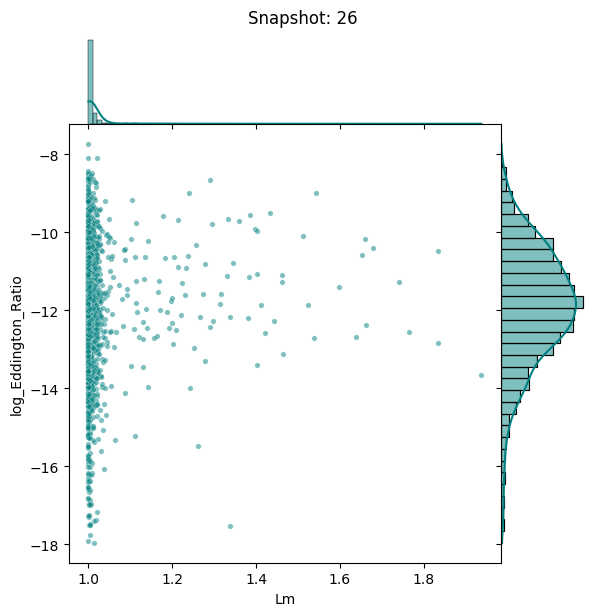

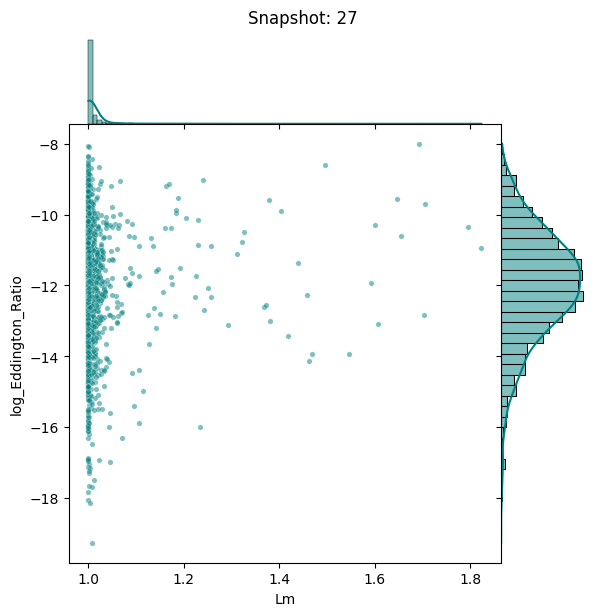

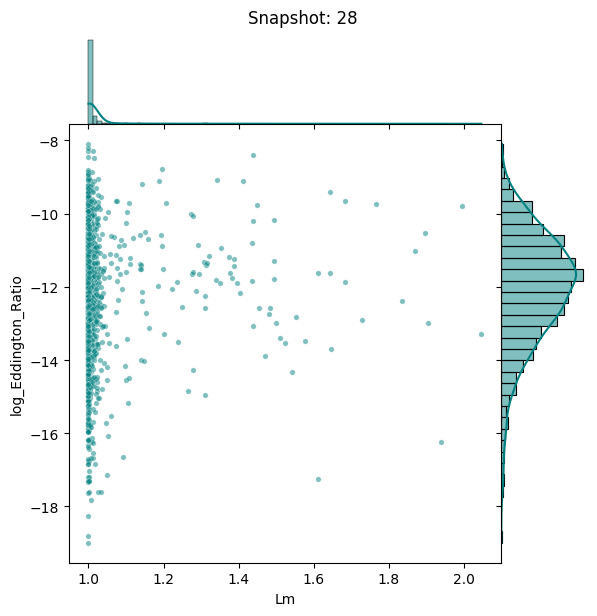

In [26]:
# Graficamos con seaborn para una visualización estática

def plot_snap(df, snap_id, var_x, var_y):
    # Filtramos con Polars
    data = df[(df["SnapNum"] == snap_id)]
    
    g = sns.JointGrid(data=data, x=var_x, y=var_y, space=0)
    g.plot_joint(sns.scatterplot, s=15, alpha=0.5, color="teal")
    g.plot_marginals(sns.histplot, kde=True, color="teal")
    g.fig.suptitle(f"Snapshot: {snap_id}", y=1.02)
    return g




df_final = (
    filtered_data
    .select([
        pl.col("SnapNum"),
        pl.col("Stars_Mass").log10().alias("log_Mstar"),
        pl.col("BlackHoleMass").log10().alias("log_MBH"),
        pl.col('12+log(O/H)'),
        pl.col('Lm'),
        (pl.col('BlackHoleMassAccretionRate')/pl.col('BlackHoleMass')).log10().alias('log_Eddington_Ratio'),
    ])
    .to_pandas() # Aquí debería funcionar si tienes pyarrow
)

# Ejemplo: Mostrar 3 momentos clave en una fila
snaps_to_show = [12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28]
for s in snaps_to_show:
    plot_snap(df_final, s, "Lm", "log_Eddington_Ratio")
    plt.show()

### Construcción del grupo que sufrió un único major merger en su historia

In [27]:
# Si nos quedamos con las galaxias que sólo sufrieron un mayor merger en toda su historia. Da un total de 731 galaxias.

filtered_ids = (
    filtered_data
    .group_by("RootGalaxyID")
    .agg(
        (pl.col("Lm") > 1.25).sum().alias("n_major_mergers")
    )
    .filter(pl.col("n_major_mergers") == 1)
    .select("RootGalaxyID")
)

result_merger = filtered_data.join(
    filtered_ids,
    on="RootGalaxyID",
    how="inner"
)

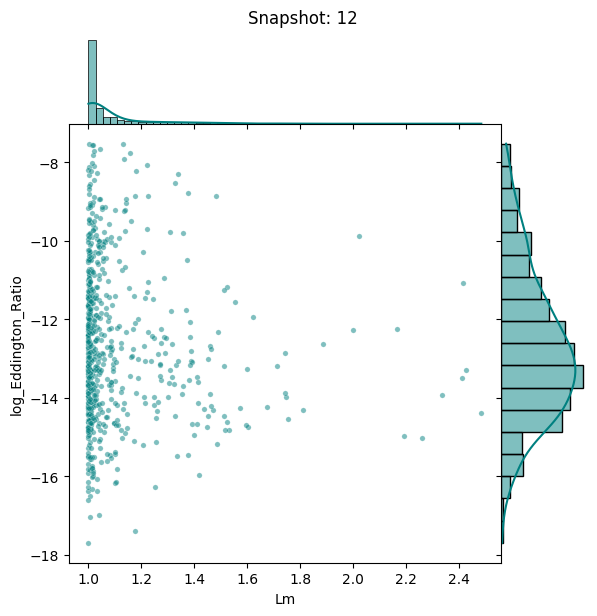

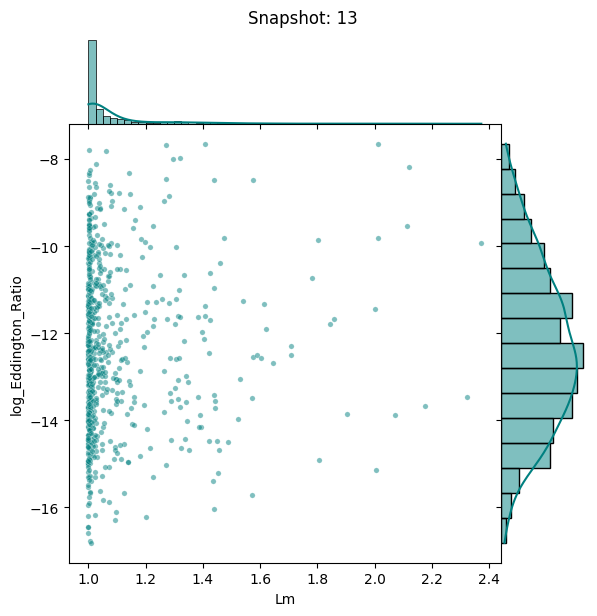

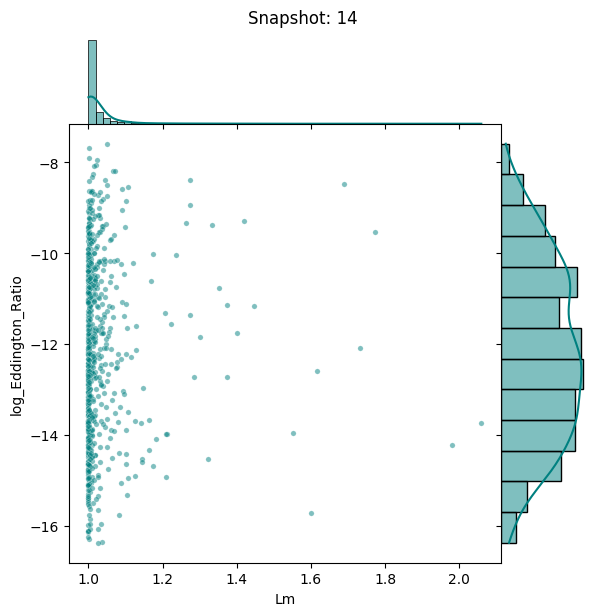

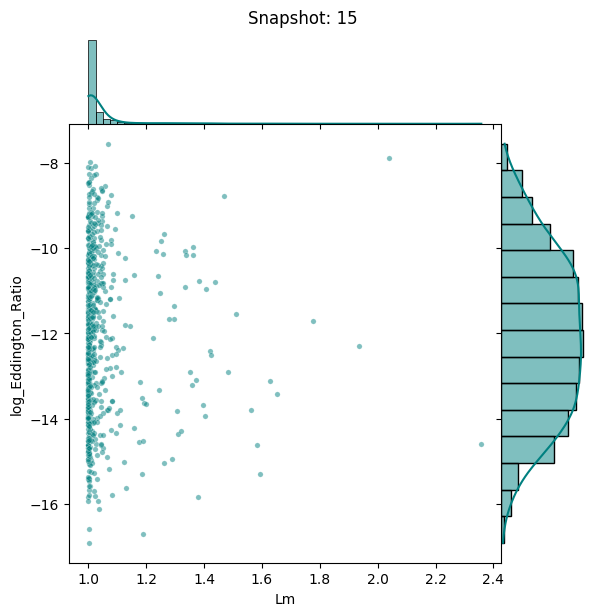

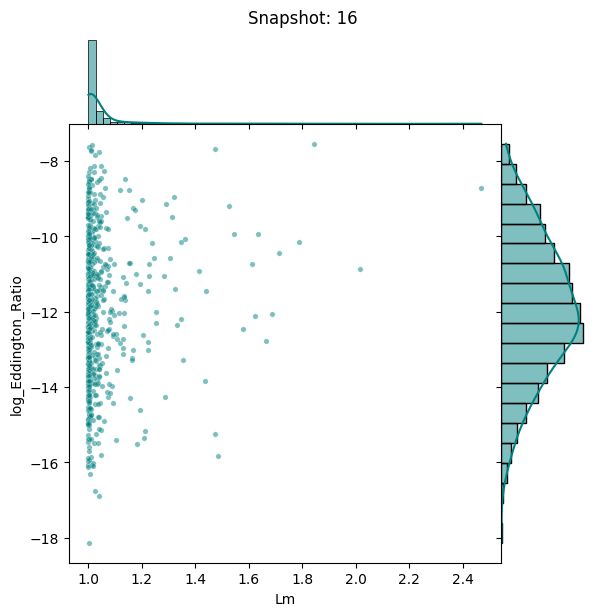

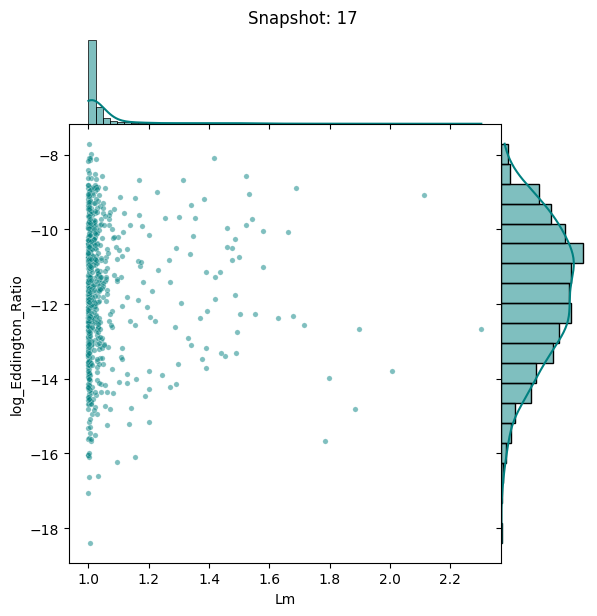

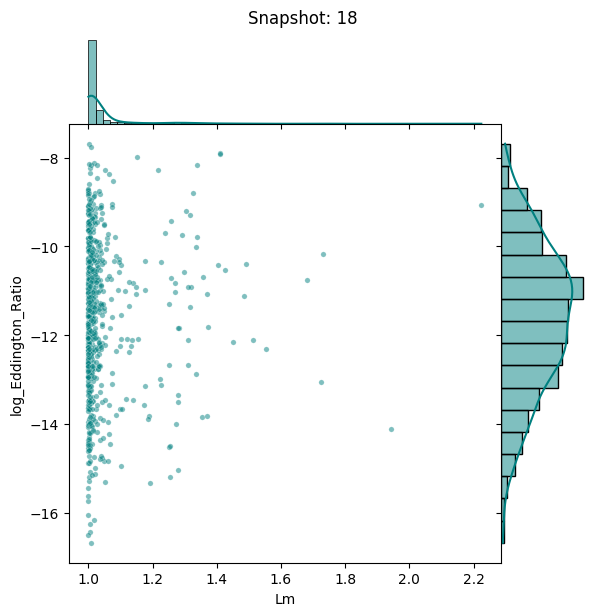

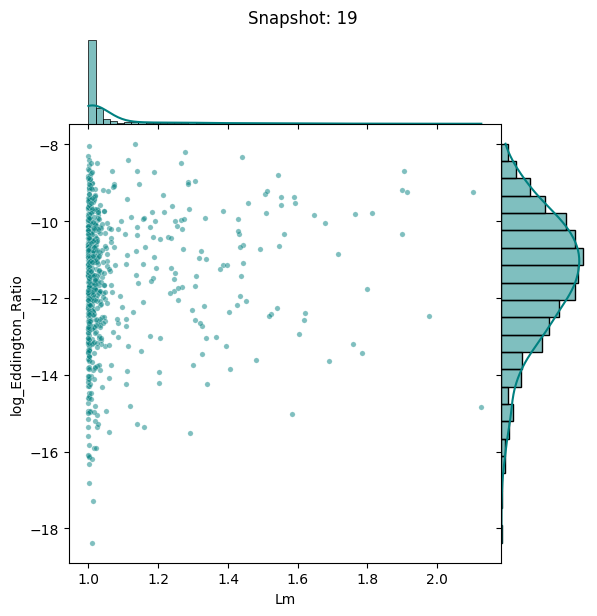

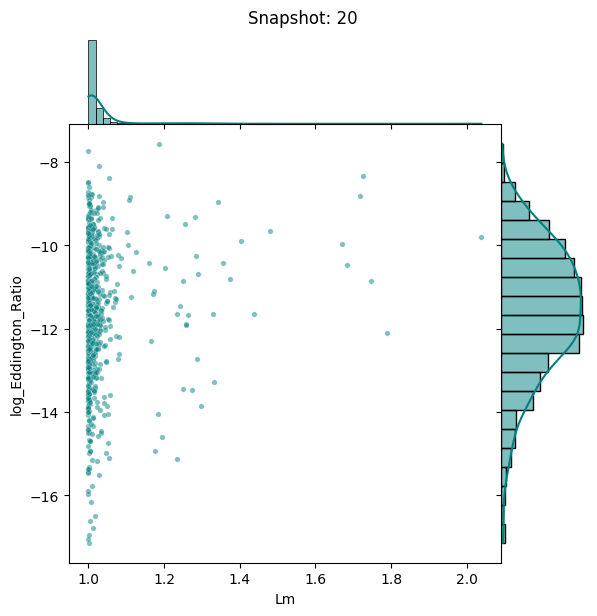

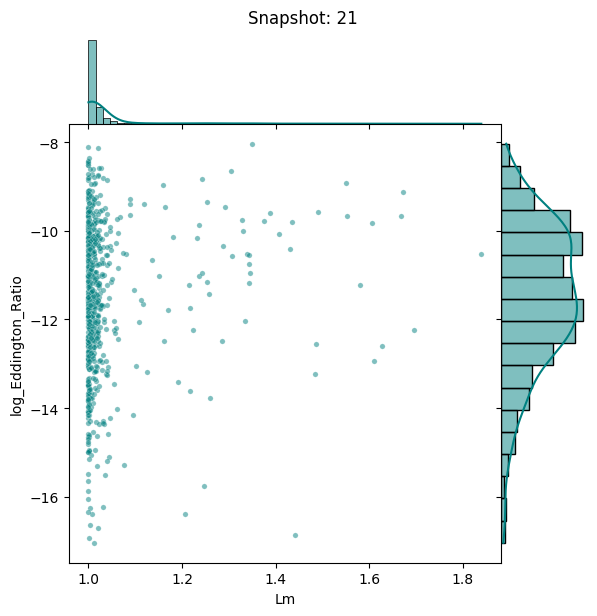

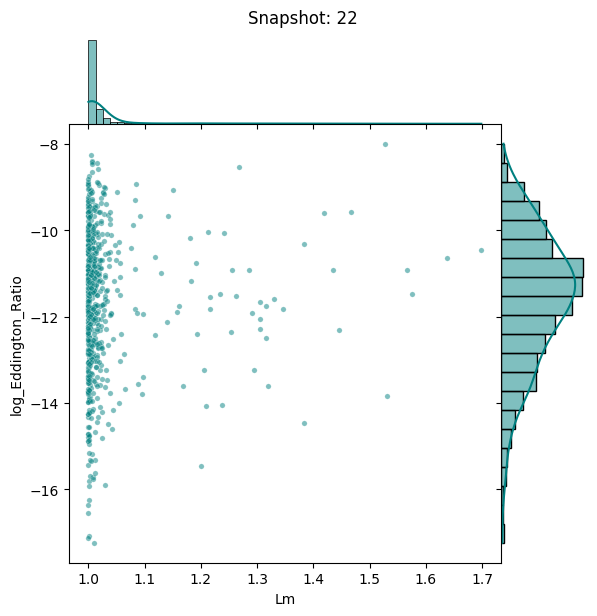

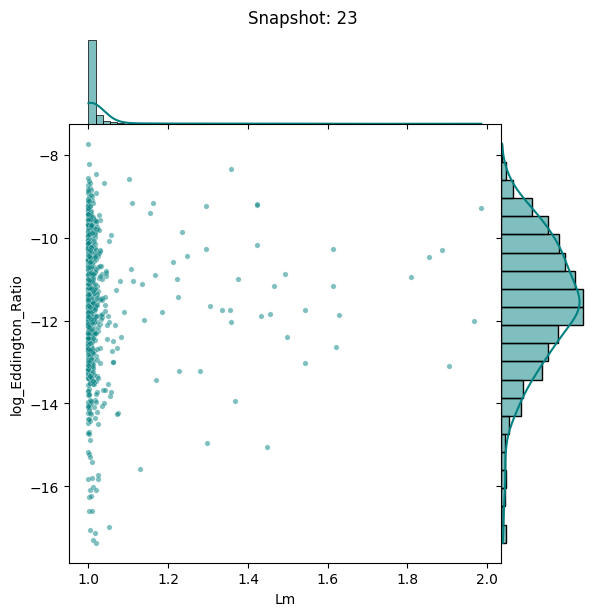

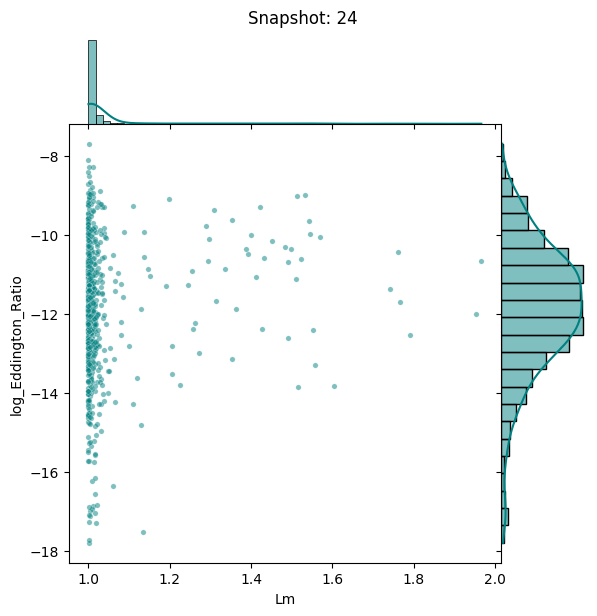

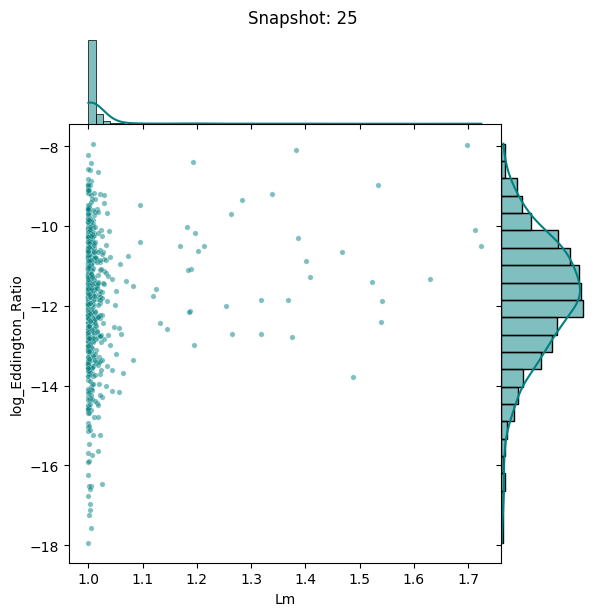

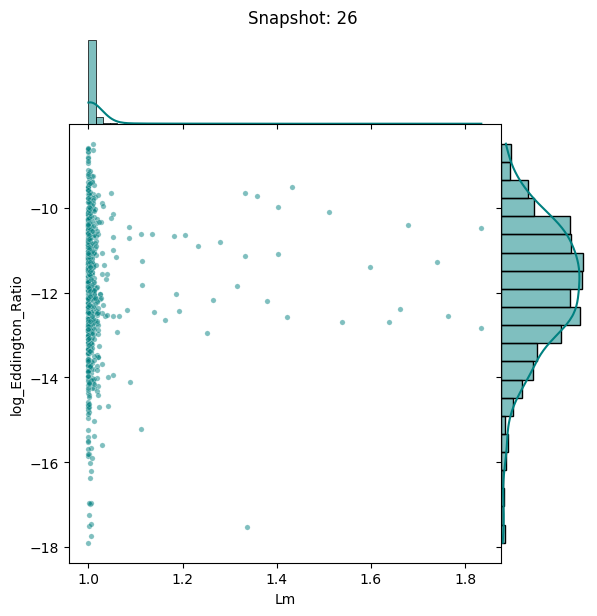

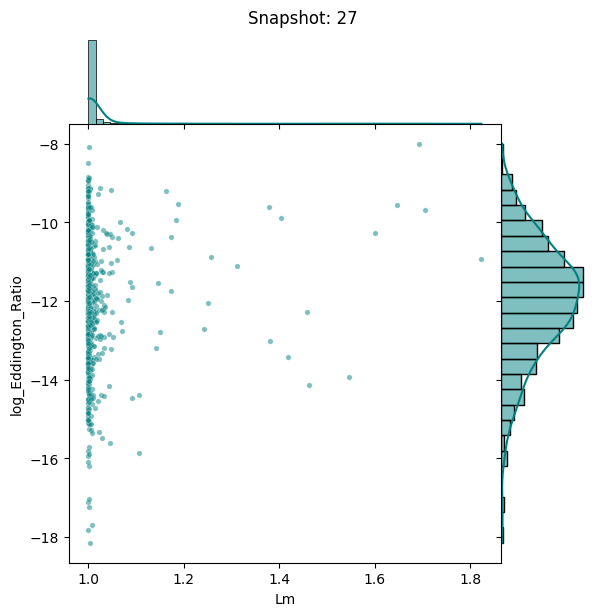

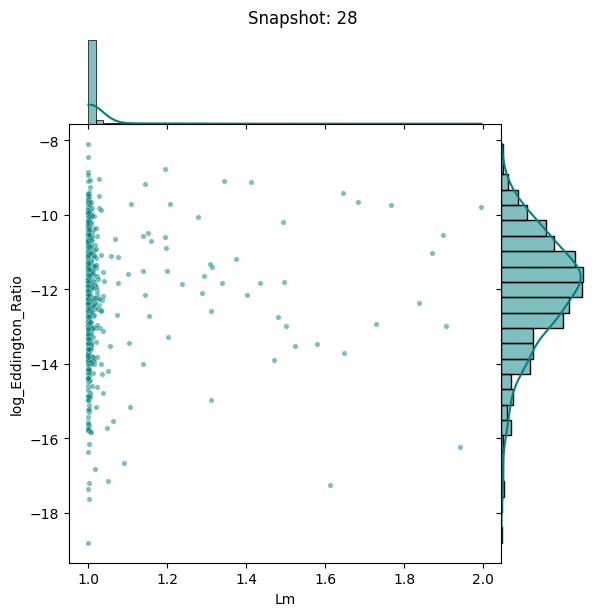

In [28]:
# Gráficos con las galaxias que sufrieron sólo un major merger en su historia
df_final = (
    result_merger
    .select([
        pl.col("SnapNum"),
        pl.col("Stars_Mass").log10().alias("log_Mstar"),
        pl.col("BlackHoleMass").log10().alias("log_MBH"),
        pl.col('12+log(O/H)'),
        pl.col('Lm'),
        (pl.col('BlackHoleMassAccretionRate')/pl.col('BlackHoleMass')).log10().alias('log_Eddington_Ratio'),
    ])
    .to_pandas() # Aquí debería funcionar si tienes pyarrow
)

# Ejemplo: Mostrar 3 momentos clave en una fila
snaps_to_show = [12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28]
for s in snaps_to_show:
    plot_snap(df_final, s, "Lm", "log_Eddington_Ratio")
    plt.show()

Lo que queremos calcular ahora es el delta t, es decir separa los registros según antes (dt<0) o después (dt>0) del merger.
La idea es cuantificar cuanto cambian las magnitudes luego del evento.

In [29]:
# Creamos delta snap para cada galaxia, que es la diferencia entre el snap actual y el snap del major merger
# Primero obtenemos el snap del major merger para cada galaxia
major_merger_snaps = (
    result_merger
    .filter(pl.col("Lm") > 1.25)
    .group_by("RootGalaxyID")
    .agg(pl.min("SnapNum").alias("Snap_Major_Merger"))
)

# Separamos tambien diferencia temporal
major_merger_time = (
    result_merger
    .filter(pl.col("Lm") > 1.25)
    .group_by("RootGalaxyID")
    .agg(pl.min("LookbackTime(Gyr)").alias("Time_Major_Merger"))
)

# Luego unimos esta información con el dataset original para calcular delta snap
result_with_delta = result_merger.join(major_merger_snaps, on="RootGalaxyID", how="left").with_columns(
    (pl.col("SnapNum") - pl.col("Snap_Major_Merger")).alias("Delta_Snap")
)

# Unimos también la información de tiempo para calcular delta tiempo
result_with_delta = result_with_delta.join(major_merger_time, on="RootGalaxyID", how="left").with_columns(
    (pl.col("LookbackTime(Gyr)") - pl.col("Time_Major_Merger")).alias("Delta_Time_Gyr")
)


In [30]:
result_with_delta

GalaxyID,SnapNum,Redshift,Stars_Mass,Stars_KineticEnergy,Stars_Spin_x,Stars_Spin_y,Stars_Spin_z,SF_Mass,SF_Oxygen,SF_Hydrogen,SF_MassWeightedTemperature,SF_KineticEnergy,SF_ThermalEnergy,SF_TotalEnergy,SF_Spin_x,SF_Spin_y,SF_Spin_z,BlackHoleMass,BlackHoleMassAccretionRate,SubHaloGalaxyID,RootGalaxyID,LookbackTime(Gyr),Lm,Log(Stars_Mass),Log(BlackHoleMass),Stars_Spin_Total,SF_Spin_Total,Total_Spin,12+log(O/H),Snap_Major_Merger,Delta_Snap,Time_Major_Merger,Delta_Time_Gyr
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64
8689661,12,3.0165045,3.9394144e8,1.4403e12,35.128006,-82.5278,-16.886503,5.6202176e8,0.002771,0.7426614,10638.657,1.1970e12,1.1670e11,-1.7340e13,33.266552,-1.250882,-68.648636,308156.72,2.3595e-10,8689661,8689645,11.68,1.005999,8.595432,5.488772,91.268661,76.294583,137.887429,8.36767,24,-12,4.12,7.56
8689660,13,2.4784133,7.279321e8,2.5715e12,-26.568527,-35.37504,13.256275,2.2182e9,0.002691,0.7423665,11189.634,9.3446e12,4.7469e11,-1.0583e14,-212.44557,-2.265337,-3.274268,308215.56,5.5702e-8,8689660,8689645,11.17,1.010501,8.862091,5.488855,46.184509,212.482876,242.165598,8.355224,24,-11,4.12,7.05
8689659,14,2.237037,1.0777e9,4.7914e12,-17.413115,-28.804552,-20.64489,2.7721e9,0.003175,0.740384,11147.517,1.1803e13,5.8834e11,-1.5415e14,-224.49707,-210.9354,177.73941,308517.6,9.4310e-9,8689659,8689645,10.87,1.006641,9.032508,5.48928,39.485824,355.645857,375.065955,8.428164,24,-10,4.12,6.75
8689658,15,2.0124102,1.5601e9,7.8809e12,-90.6459,-35.008163,-69.34195,3.6081e9,0.003697,0.738451,11750.763,1.5774e13,8.0621e11,-2.1217e14,-132.1504,-204.31976,-20.6284,309547.78,0.000001,8689658,8689645,10.54,1.0,9.193159,5.490728,119.375696,244.204471,339.13229,8.495363,24,-9,4.12,6.42
8689657,16,1.7369658,2.5613e9,1.6582e13,5.2884703,8.26441,-261.4432,5.5089e9,0.003984,0.7371053,11742.4795,3.4445e13,1.2367e12,-3.4529e14,-491.50455,-172.54085,-301.07648,494658.6,8.9021e-9,8689657,8689645,10.05,1.03792,9.408453,5.694306,261.627245,601.659467,761.459924,8.528717,24,-8,4.12,5.93
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
21986365,24,0.365669,8.0355e11,1.3398e17,-8157.2715,-4815.6025,-7921.742,1.5845e10,0.009007,0.7135603,14842.011,1.4543e15,4.3683e12,-1.8960e16,18130.81,-38427.527,-3099.3567,1.0961e9,0.00445,21986365,21986361,4.12,1.001543,11.905013,9.039858,12348.485821,42602.900307,45726.407422,8.897018,17,7,9.49,-5.37
21986364,25,0.270901,9.1478e11,2.1425e17,-3263.4863,-13905.607,-23574.283,1.4140e10,0.009128,0.7106501,15650.902,2.7811e15,4.1468e12,-1.6325e16,13426.726,-36767.79,-18871.074,1.1888e9,0.012013,21986364,21986361,3.24,1.000458,11.961315,9.075116,27563.799953,43454.168804,66878.194769,8.904597,17,8,9.49,-6.25
21986363,26,0.18271,1.0332e12,1.9705e17,-2159.21,-12064.919,-21040.172,1.0932e10,0.00931,0.711415,13835.004,1.2363e15,2.7834e12,-1.4122e16,12981.541,-47848.95,-39117.74,8.605493e8,0.000002,21986363,21986361,2.32,1.041736,12.014164,8.934776,24349.811007,63152.51385,85590.705821,8.912693,17,9,9.49,-7.17


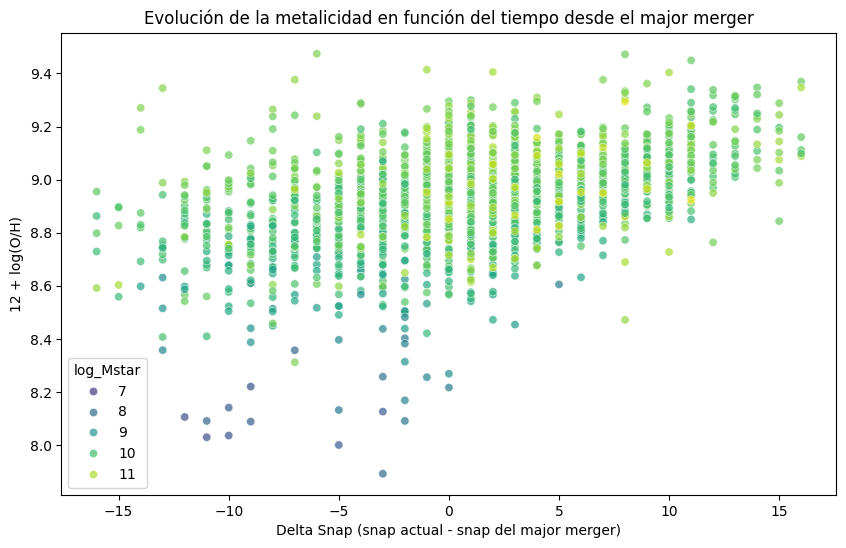

In [47]:
df =result_with_delta.filter( pl.col('BlackHoleMassAccretionRate')/pl.col('BlackHoleMass') > 1e-10 ).with_columns(
    pl.col("Delta_Snap").alias("Delta_Snap"),
    pl.col("Stars_Mass").log10().alias("log_Mstar"),
    pl.col("SnapNum").alias("SnapNum"),
    pl.col("Delta_Time_Gyr").alias("Delta_Time_Gyr"),
    pl.col("Lm").alias("Lm"),
    pl.col("12+log(O/H)").alias("12+log(O/H)"),
    (pl.col('BlackHoleMassAccretionRate')/pl.col('BlackHoleMass')).log10().alias('log_Eddington_Ratio')).to_pandas()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Delta_Snap", y="12+log(O/H)", hue="log_Mstar", palette="viridis", alpha=0.7)
plt.title("Evolución de la metalicidad en función del tiempo desde el major merger")
plt.xlabel("Delta Snap (snap actual - snap del major merger)")
plt.ylabel("12 + log(O/H)")
plt.legend(title="log_Mstar")
plt.show()

### Nos quedamos con las galaxias que no sufrieron major merger (L<1.1)

In [36]:
# Si nos quedamos con las galaxias que sólo sufrieron un mayor merger en toda su historia. Da un total de 731 galaxias.

filtered_ids = (
    filtered_data
    .group_by("RootGalaxyID")
    .agg(
        (pl.col("Lm") > 1.1).sum().alias("n_major_mergers")
    )
    .filter(pl.col("n_major_mergers") == 0)
    .select("RootGalaxyID")
)

result_sin_merger = filtered_data.join(
    filtered_ids,
    on="RootGalaxyID",
    how="inner"
)

In [37]:
result_sin_merger

GalaxyID,SnapNum,Redshift,Stars_Mass,Stars_KineticEnergy,Stars_Spin_x,Stars_Spin_y,Stars_Spin_z,SF_Mass,SF_Oxygen,SF_Hydrogen,SF_MassWeightedTemperature,SF_KineticEnergy,SF_ThermalEnergy,SF_TotalEnergy,SF_Spin_x,SF_Spin_y,SF_Spin_z,BlackHoleMass,BlackHoleMassAccretionRate,SubHaloGalaxyID,RootGalaxyID,LookbackTime(Gyr),Lm,Log(Stars_Mass),Log(BlackHoleMass),Stars_Spin_Total,SF_Spin_Total,Total_Spin,12+log(O/H)
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64
8653550,12,3.0165045,1.6308e9,8.3357e12,-182.27911,78.35497,46.508324,3.4583e9,0.003617,0.7393855,13539.097,1.3628e13,8.9587e11,-2.4161e14,-162.62936,119.137375,79.42462,154722.81,0.000031,8653550,8653534,11.68,1.004189,9.212393,5.189554,203.784689,216.680163,416.922277,8.485391
8653549,13,2.4784133,2.8053e9,2.2097e13,36.569813,44.937973,74.99895,5.4007e9,0.004049,0.73697,13646.755,4.6142e13,1.4081e12,-4.0170e14,96.99059,172.99303,174.45464,307258.1,0.000006,8653549,8653534,11.17,1.013103,9.44798,5.487503,94.771384,264.136677,357.154584,8.535732
8653548,14,2.237037,3.6140e9,2.9982e13,-39.82108,90.77089,14.150645,5.7847e9,0.00486,0.733242,12839.271,4.2109e13,1.4135e12,-4.8090e14,195.72488,-47.31469,-196.69492,309055.78,7.3232e-8,8653548,8653534,10.87,1.0,9.557985,5.490037,100.126488,281.488543,243.960752,8.617293
8653547,15,2.0124102,4.8833e9,4.3815e13,10.991171,36.32706,15.543257,7.3691e9,0.005296,0.730739,14658.0205,6.3805e13,2.0703e12,-6.7783e14,252.59706,-18.684078,-359.6169,317502.4,6.0724e-7,8653547,8653534,10.54,1.000633,9.688712,5.501747,41.012851,439.86212,433.793386,8.656052
8653546,16,1.7369658,6.8806e9,6.1949e13,113.73962,-121.56003,-72.10062,8.1505e9,0.006577,0.724292,13537.02,8.5284e13,2.1148e12,-7.0847e14,458.99432,-420.47247,-624.63226,481528.22,0.000002,8653546,8653534,10.05,1.000469,9.837626,5.682622,181.416762,881.838049,1052.264274,8.753995
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
20089291,24,0.365669,9.1679e10,4.2474e15,-153.08453,-4452.9395,-127.37669,1.2124e10,0.014002,0.6799739,11181.728,5.5505e14,2.2893e12,-3.6891e15,-672.1761,-4707.2607,-1540.2056,6.1997092e7,0.000305,20089291,20089287,4.12,1.014168,10.962269,7.792371,4457.390479,4998.235418,9347.253795,9.109592
20089290,25,0.270901,1.1053e11,4.2854e15,-1293.499,-1562.8993,579.4412,9.9021e9,0.012858,0.6871318,12891.184,2.5941e14,2.2051e12,-3.9307e15,-1514.0292,-24.657835,1323.3857,7.166942e7,0.00013,20089290,20089287,3.24,1.00447,11.043486,7.855334,2109.868714,2011.030119,3744.770015,9.068027
20089289,26,0.18271,1.2784e11,6.0558e15,-1433.5149,-2259.97,1755.8264,8.0197e9,0.015514,0.6707716,16875.46,2.4235e14,2.4825e12,-3.6471e15,-1714.2263,-148.71985,2234.9023,1.5976472e8,0.003767,20089289,20089287,2.32,1.046769,11.106682,8.203481,3200.836721,2820.545637,5624.58683,9.160037


## Sobre la simu NoAGNL0050N0752

In [3]:
# Cargamos los datos de la tabla de galaxias centrales
data_centrales_no = pl.read_csv('data/tracks_centrales_NoAGNL0050N0752_snap28.csv')

# Cargamos los datos de las fusines
data_fusiones_no = pl.read_csv('data/historial_merger_centrales_NoAGNL0050N0752_snap28.csv')

In [4]:
# Información hisórica del desarrollo de las galaxias centrales
data_centrales_no

GalaxyID,SnapNum,Redshift,Stars_Mass,Stars_KineticEnergy,Stars_Spin_x,Stars_Spin_y,Stars_Spin_z,SF_Mass,SF_Oxygen,SF_Hydrogen,SF_MassWeightedTemperature,SF_KineticEnergy,SF_ThermalEnergy,SF_TotalEnergy,SF_Spin_x,SF_Spin_y,SF_Spin_z,SubHaloGalaxyID,RootGalaxyID
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64
1620608,12,3.016505,4.6549e9,4.7754e13,-110.17007,-113.38382,-1.597729,9.9129e9,0.004171,0.7369519,14096.6045,1.1861e14,2.6294e12,-1.0474e15,-11.874759,-203.96361,-355.9548,1620608,1620592
1620607,13,2.478413,8.9888e9,2.2588e14,-179.57306,269.90918,186.75658,1.6828e10,0.004805,0.7333201,19545.84,4.3473e14,6.3381e12,-2.7079e15,-137.959,-132.17921,269.66498,1620607,1620592
1620606,14,2.237037,1.4998e10,3.2201e14,-257.9472,83.82947,216.85909,1.8747e10,0.007965,0.7193629,26476.67,3.7830e14,9.6395e12,-3.8851e15,-546.21814,12.207579,289.3705,1620606,1620592
1620605,15,2.01241,2.0967e10,4.6505e14,-299.38834,122.41683,257.0124,1.6859e10,0.011262,0.7015376,27409.744,3.6749e14,8.9570e12,-3.6810e15,-598.54156,236.10997,243.31071,1620605,1620592
1620604,16,1.736966,2.6801e10,5.8635e14,-276.64853,223.81375,194.02141,1.5091e10,0.013725,0.684758,19762.441,3.8680e14,5.7172e12,-2.9602e15,-725.20807,723.84174,366.2823,1620604,1620592
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3265057,24,0.365669,1.0505e10,8.4338e13,447.7758,143.79854,-1554.3646,6.4188e9,0.008075,0.714317,6997.231,6.0414e13,8.1927e11,-3.5340e14,722.30536,118.801414,-2687.993,3265057,3265053
3265056,25,0.270901,1.1977e10,1.0469e14,328.4866,131.89937,-1642.1791,7.3717e9,0.00804,0.7146269,6557.0,8.1380e13,8.7856e11,-4.1497e14,522.4535,25.953718,-3046.804,3265056,3265053
3265055,26,0.18271,1.3769e10,1.2435e14,185.88054,115.28082,-2014.6118,6.2686e9,0.009385,0.7077579,5991.1514,7.0693e13,7.0782e11,-3.8186e14,253.53828,57.120804,-3069.684,3265055,3265053


In [5]:
# Le agregamos una columna de tiempo a la tabla de galaxias centrales usando el diccionario de snaps a tiempos
# Diccionario para mapear los snaps a tiempos aproximados en Gyr
snap_to_time = {12:11.68, 13:11.17, 14:10.87, 15:10.54, 16:10.05, 17:9.49, 18:8.86, 19: 7.96,
                20: 7.35, 21:6.69, 22: 5.98, 23: 5.22, 24: 4.12, 25: 3.24, 26: 2.32, 27: 1.35, 28: 0}
map_df = pl.DataFrame({
    "SnapNum": list(snap_to_time.keys()),
    "LookbackTime(Gyr)": list(snap_to_time.values())
})

data_centrales_no = data_centrales_no.join(map_df, on="SnapNum", how="left")

In [6]:
data_centrales_no

GalaxyID,SnapNum,Redshift,Stars_Mass,Stars_KineticEnergy,Stars_Spin_x,Stars_Spin_y,Stars_Spin_z,SF_Mass,SF_Oxygen,SF_Hydrogen,SF_MassWeightedTemperature,SF_KineticEnergy,SF_ThermalEnergy,SF_TotalEnergy,SF_Spin_x,SF_Spin_y,SF_Spin_z,SubHaloGalaxyID,RootGalaxyID,LookbackTime(Gyr)
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64
1620608,12,3.016505,4.6549e9,4.7754e13,-110.17007,-113.38382,-1.597729,9.9129e9,0.004171,0.7369519,14096.6045,1.1861e14,2.6294e12,-1.0474e15,-11.874759,-203.96361,-355.9548,1620608,1620592,11.68
1620607,13,2.478413,8.9888e9,2.2588e14,-179.57306,269.90918,186.75658,1.6828e10,0.004805,0.7333201,19545.84,4.3473e14,6.3381e12,-2.7079e15,-137.959,-132.17921,269.66498,1620607,1620592,11.17
1620606,14,2.237037,1.4998e10,3.2201e14,-257.9472,83.82947,216.85909,1.8747e10,0.007965,0.7193629,26476.67,3.7830e14,9.6395e12,-3.8851e15,-546.21814,12.207579,289.3705,1620606,1620592,10.87
1620605,15,2.01241,2.0967e10,4.6505e14,-299.38834,122.41683,257.0124,1.6859e10,0.011262,0.7015376,27409.744,3.6749e14,8.9570e12,-3.6810e15,-598.54156,236.10997,243.31071,1620605,1620592,10.54
1620604,16,1.736966,2.6801e10,5.8635e14,-276.64853,223.81375,194.02141,1.5091e10,0.013725,0.684758,19762.441,3.8680e14,5.7172e12,-2.9602e15,-725.20807,723.84174,366.2823,1620604,1620592,10.05
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3265057,24,0.365669,1.0505e10,8.4338e13,447.7758,143.79854,-1554.3646,6.4188e9,0.008075,0.714317,6997.231,6.0414e13,8.1927e11,-3.5340e14,722.30536,118.801414,-2687.993,3265057,3265053,4.12
3265056,25,0.270901,1.1977e10,1.0469e14,328.4866,131.89937,-1642.1791,7.3717e9,0.00804,0.7146269,6557.0,8.1380e13,8.7856e11,-4.1497e14,522.4535,25.953718,-3046.804,3265056,3265053,3.24
3265055,26,0.18271,1.3769e10,1.2435e14,185.88054,115.28082,-2014.6118,6.2686e9,0.009385,0.7077579,5991.1514,7.0693e13,7.0782e11,-3.8186e14,253.53828,57.120804,-3069.684,3265055,3265053,2.32


In [7]:
# Historial de fusiones de las galaxias centrales
data_fusiones_no

GalaxyID,Snapshot,Lm
i64,i64,f64
1620592,3,1.0
1620592,4,1.0
1620592,5,1.0
1620592,6,2.777111
1620592,7,1.048094
…,…,…
3265053,24,1.088847
3265053,25,1.013717
3265053,26,1.114868


In [8]:
# Unimos las tablas para obtener una visión completa de la evolución de las galaxias centrales
new_data_no = data_centrales_no.join(data_fusiones_no , left_on=['RootGalaxyID','SnapNum'], right_on=['GalaxyID','Snapshot'], how='left')

new_data_no

GalaxyID,SnapNum,Redshift,Stars_Mass,Stars_KineticEnergy,Stars_Spin_x,Stars_Spin_y,Stars_Spin_z,SF_Mass,SF_Oxygen,SF_Hydrogen,SF_MassWeightedTemperature,SF_KineticEnergy,SF_ThermalEnergy,SF_TotalEnergy,SF_Spin_x,SF_Spin_y,SF_Spin_z,SubHaloGalaxyID,RootGalaxyID,LookbackTime(Gyr),Lm
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64
1620608,12,3.016505,4.6549e9,4.7754e13,-110.17007,-113.38382,-1.597729,9.9129e9,0.004171,0.7369519,14096.6045,1.1861e14,2.6294e12,-1.0474e15,-11.874759,-203.96361,-355.9548,1620608,1620592,11.68,1.015702
1620607,13,2.478413,8.9888e9,2.2588e14,-179.57306,269.90918,186.75658,1.6828e10,0.004805,0.7333201,19545.84,4.3473e14,6.3381e12,-2.7079e15,-137.959,-132.17921,269.66498,1620607,1620592,11.17,1.058314
1620606,14,2.237037,1.4998e10,3.2201e14,-257.9472,83.82947,216.85909,1.8747e10,0.007965,0.7193629,26476.67,3.7830e14,9.6395e12,-3.8851e15,-546.21814,12.207579,289.3705,1620606,1620592,10.87,1.04342
1620605,15,2.01241,2.0967e10,4.6505e14,-299.38834,122.41683,257.0124,1.6859e10,0.011262,0.7015376,27409.744,3.6749e14,8.9570e12,-3.6810e15,-598.54156,236.10997,243.31071,1620605,1620592,10.54,1.000304
1620604,16,1.736966,2.6801e10,5.8635e14,-276.64853,223.81375,194.02141,1.5091e10,0.013725,0.684758,19762.441,3.8680e14,5.7172e12,-2.9602e15,-725.20807,723.84174,366.2823,1620604,1620592,10.05,1.000059
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3265057,24,0.365669,1.0505e10,8.4338e13,447.7758,143.79854,-1554.3646,6.4188e9,0.008075,0.714317,6997.231,6.0414e13,8.1927e11,-3.5340e14,722.30536,118.801414,-2687.993,3265057,3265053,4.12,1.088847
3265056,25,0.270901,1.1977e10,1.0469e14,328.4866,131.89937,-1642.1791,7.3717e9,0.00804,0.7146269,6557.0,8.1380e13,8.7856e11,-4.1497e14,522.4535,25.953718,-3046.804,3265056,3265053,3.24,1.013717
3265055,26,0.18271,1.3769e10,1.2435e14,185.88054,115.28082,-2014.6118,6.2686e9,0.009385,0.7077579,5991.1514,7.0693e13,7.0782e11,-3.8186e14,253.53828,57.120804,-3069.684,3265055,3265053,2.32,1.114868


In [9]:
# Trabajamos con galaxias que no hayan tenido en su historia fusiones mayores a un Lm mayor a 2.5.
# Me guardo el ID de las galaxias que cumplen esta condición para luego filtrar el dataset original

list_id = new_data_no.group_by('RootGalaxyID').agg(pl.max('Lm').alias('max')).filter(pl.col('max') < 2.5).select('RootGalaxyID')
#new_data.group_by('RootGalaxyID').agg(pl.max('Lm').alias('max')).filter(pl.col('max') < 2.5).select('RootGalaxyID')

mask_id = (pl.col('RootGalaxyID').is_in(list_id['RootGalaxyID']))

# Filtramos el dataset original para quedarnos solo con las galaxias que cumplen la condición
filtered_data_no = new_data_no.filter(mask_id)

/tmp/ipykernel_7009/671488468.py:10: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  filtered_data_no = new_data_no.filter(mask_id)


In [11]:
# Calculamos variables adicionales para el análisis


filtered_data_no = filtered_data_no.with_columns(
    # Logaritmos
    pl.col('Stars_Mass').log10().alias('Log(Stars_Mass)'),
    #pl.col('BlackHoleMass').log10().alias('Log(BlackHoleMass)'),
    
    # Norma de Stars_Spin (usando una expresión más limpia)
    (pl.col('Stars_Spin_x')**2 + pl.col('Stars_Spin_y')**2 + pl.col('Stars_Spin_z')**2)
    .sqrt().alias('Stars_Spin_Total'),
    
    # Norma de SF_Spin
    (pl.col('SF_Spin_x')**2 + pl.col('SF_Spin_y')**2 + pl.col('SF_Spin_z')**2)
    .sqrt().alias('SF_Spin_Total'),
    
    # Norma del Spin de gas SF y Stars
    ((pl.col('SF_Spin_x')+pl.col('Stars_Spin_x'))**2 + (pl.col('SF_Spin_y')+pl.col('Stars_Spin_y'))**2 + (pl.col('SF_Spin_z')+pl.col('Stars_Spin_z'))**2)
    .sqrt().alias('Total_Spin'),
    
    # Calculo de metalicidad.
    (12 + pl.col('SF_Oxygen').log10() - pl.col('SF_Hydrogen').log10()-np.log10(16)).alias('12+log(O/H)')
)

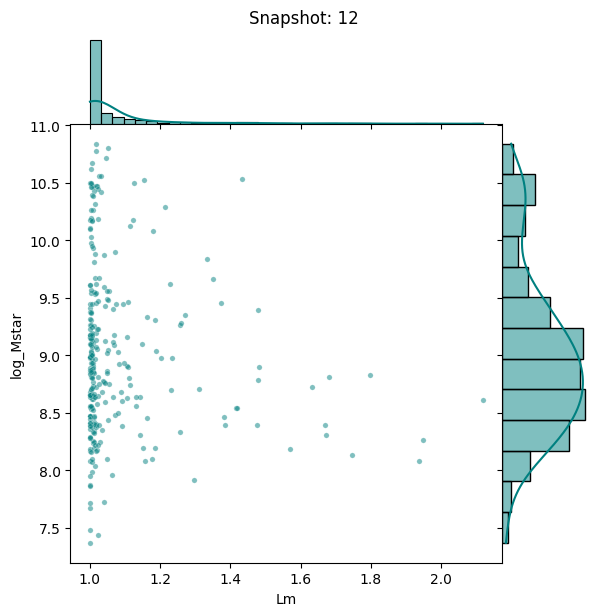

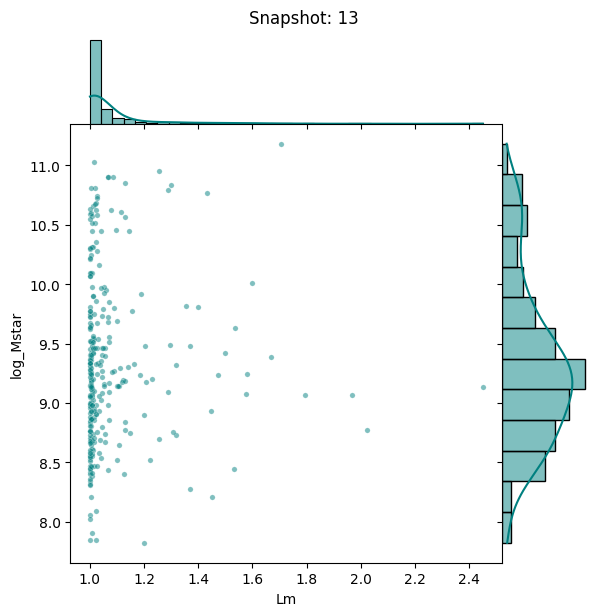

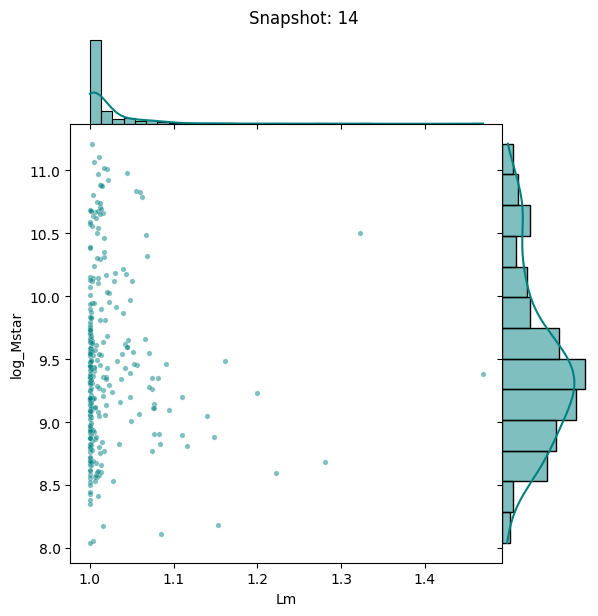

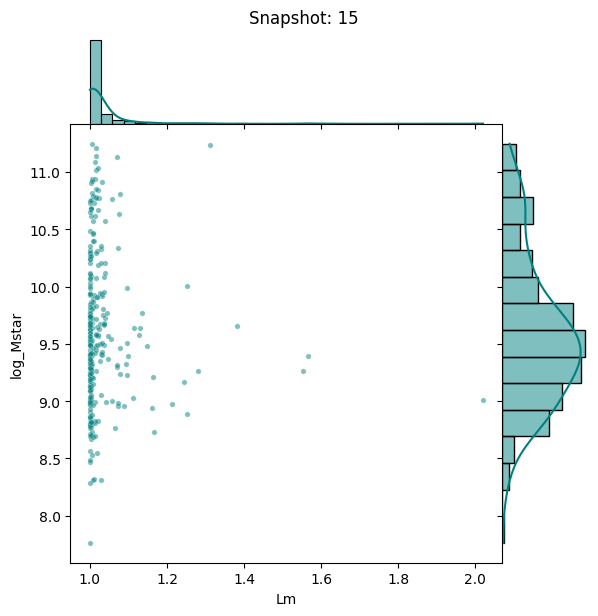

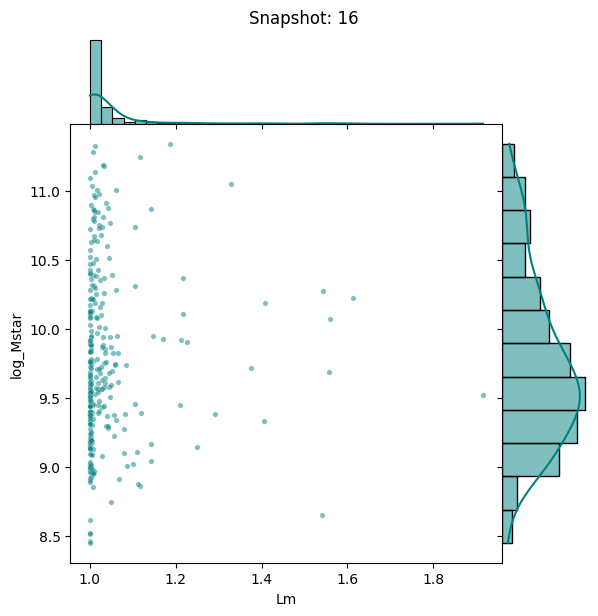

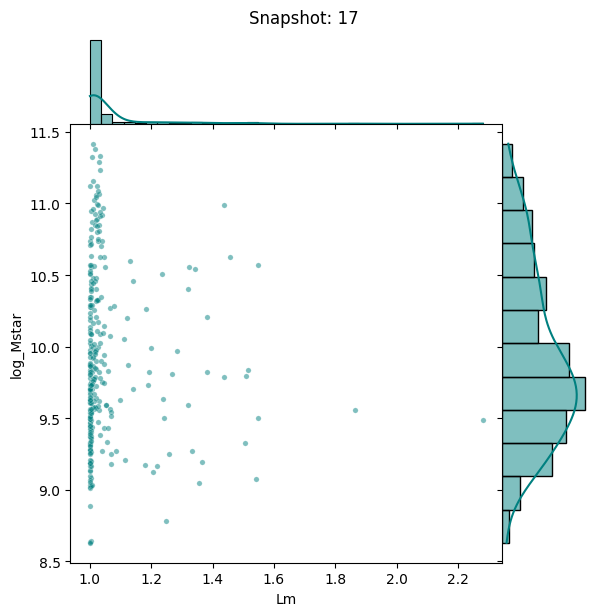

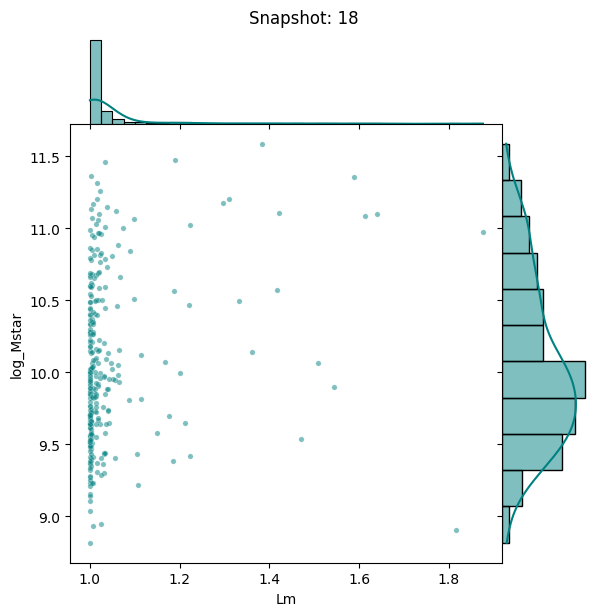

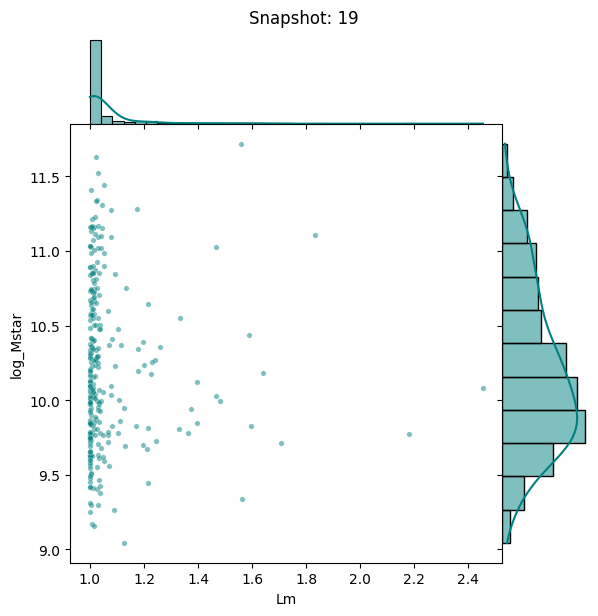

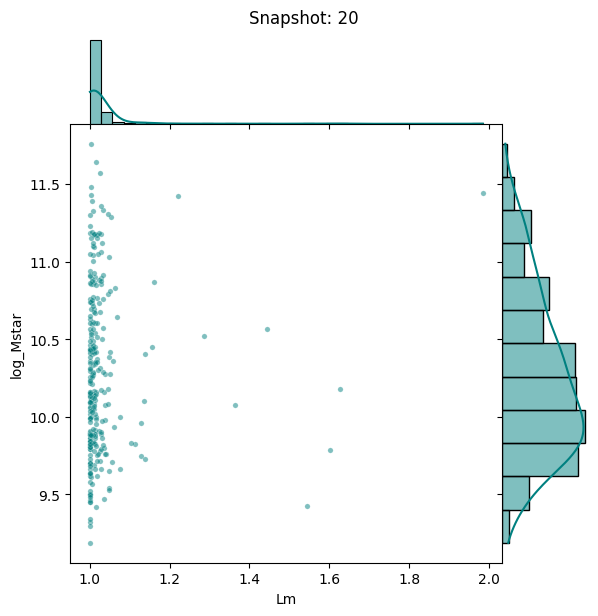

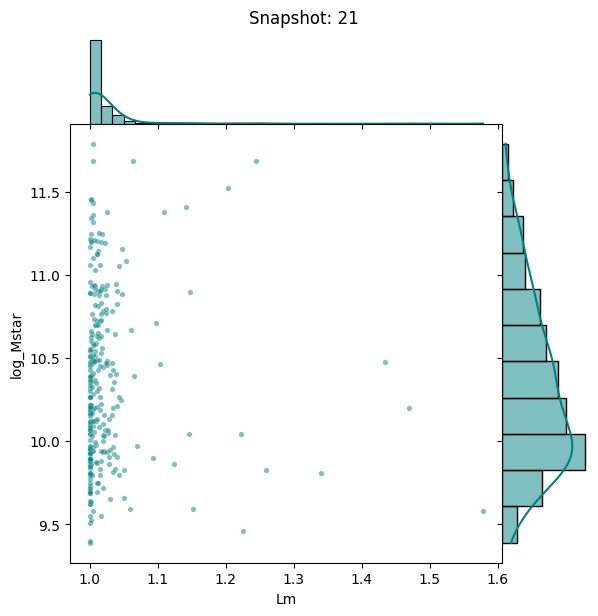

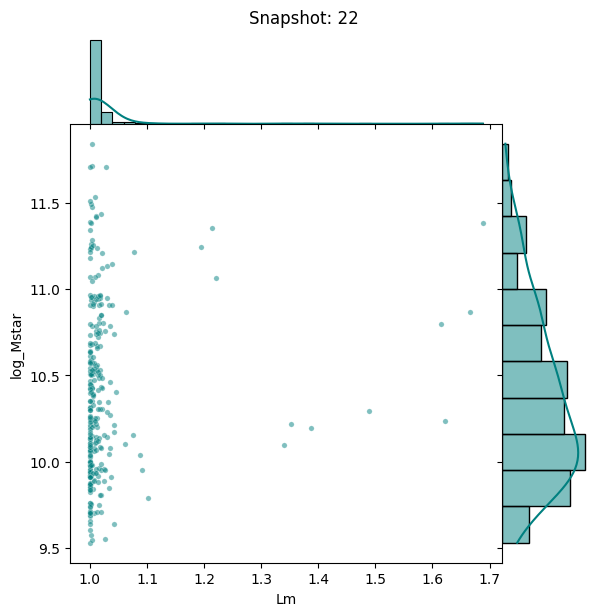

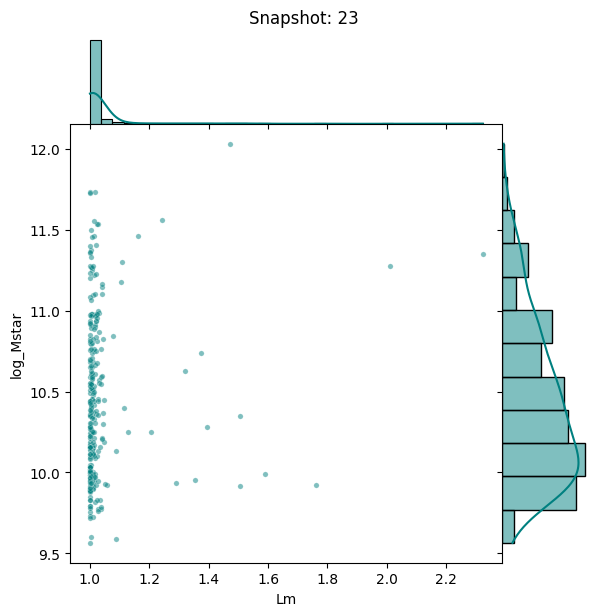

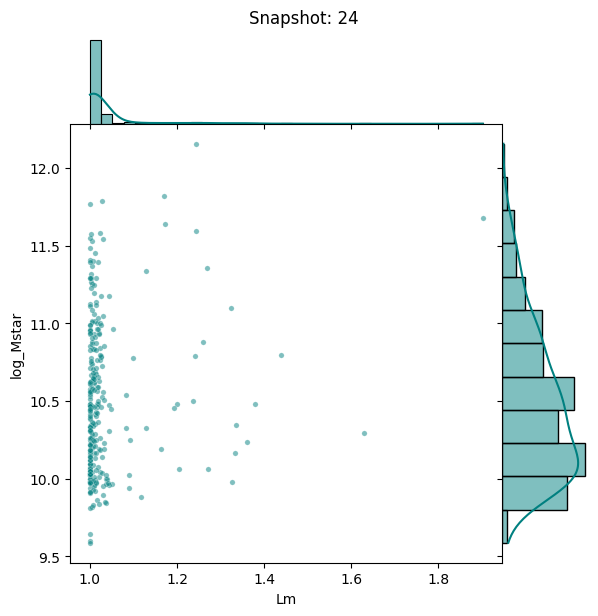

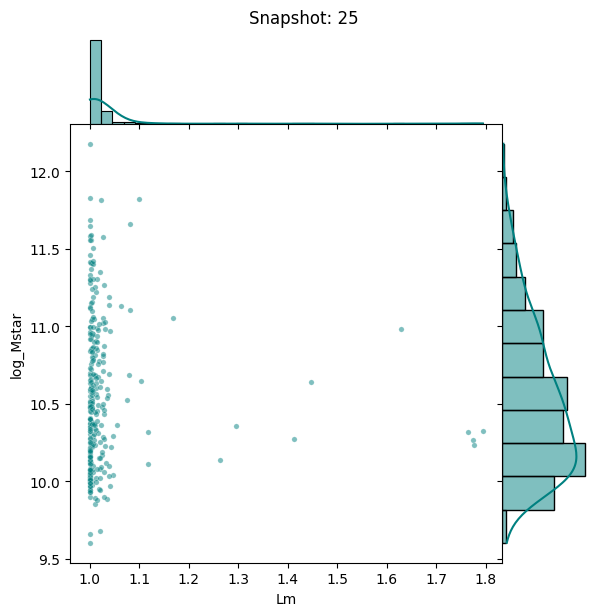

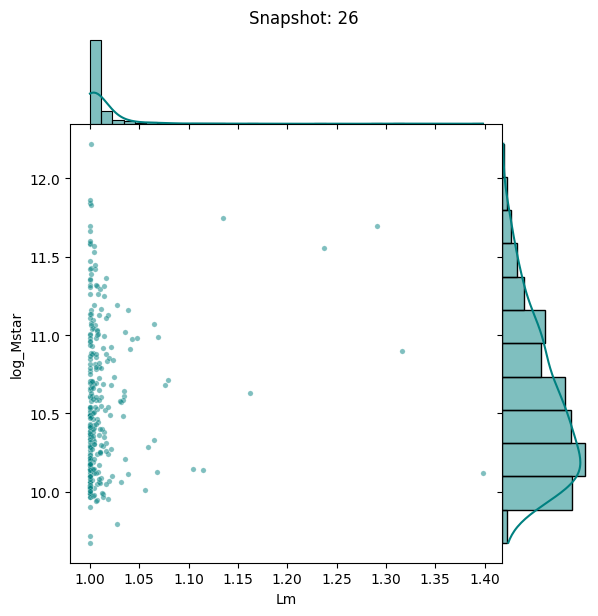

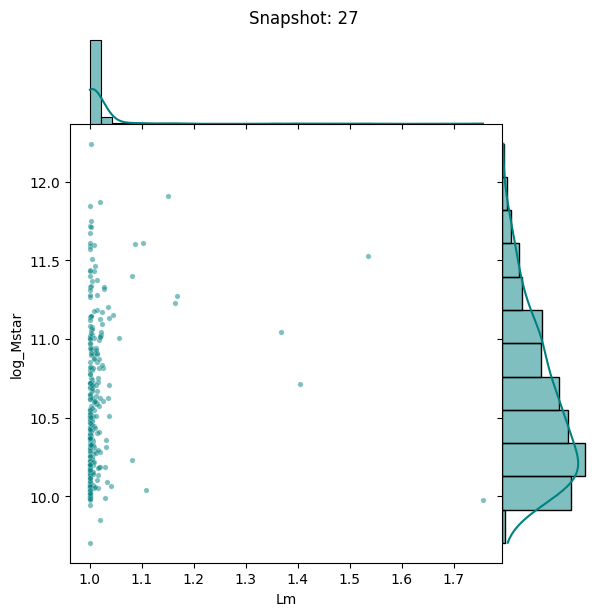

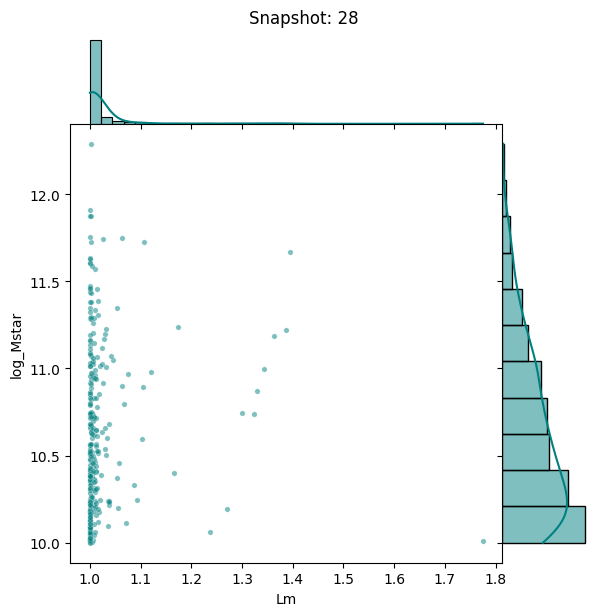

In [12]:
# Graficamos con seaborn para una visualización estática

def plot_snap(df, snap_id, var_x, var_y):
    # Filtramos con Polars
    data = df[(df["SnapNum"] == snap_id)]
    
    g = sns.JointGrid(data=data, x=var_x, y=var_y, space=0)
    g.plot_joint(sns.scatterplot, s=15, alpha=0.5, color="teal")
    g.plot_marginals(sns.histplot, kde=True, color="teal")
    g.fig.suptitle(f"Snapshot: {snap_id}", y=1.02)
    return g




df_final = (
    filtered_data_no
    .select([
        pl.col("SnapNum"),
        pl.col("Stars_Mass").log10().alias("log_Mstar"),
        #pl.col("BlackHoleMass").log10().alias("log_MBH"),
        pl.col('12+log(O/H)'),
        pl.col('Lm'),
       #(pl.col('BlackHoleMassAccretionRate')/pl.col('BlackHoleMass')).log10().alias('log_Eddington_Ratio'),
    ])
    .to_pandas() # Aquí debería funcionar si tienes pyarrow
)

# Ejemplo: Mostrar 3 momentos clave en una fila
snaps_to_show = [12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28]
for s in snaps_to_show:
    plot_snap(df_final, s, "Lm", "log_Mstar")
    plt.show()

### Construcción del grupo que sufrió un único major merger en su historia

In [ ]:

filtered_ids = (
    filtered_data_no
    .group_by("RootGalaxyID")
    .agg(
        (pl.col("Lm") > 1.25).sum().alias("n_major_mergers")
    )
    .filter(pl.col("n_major_mergers") == 1)
    .select("RootGalaxyID")
)

result_merger_no = filtered_data_no.join(
    filtered_ids,
    on="RootGalaxyID",
    how="inner"
)

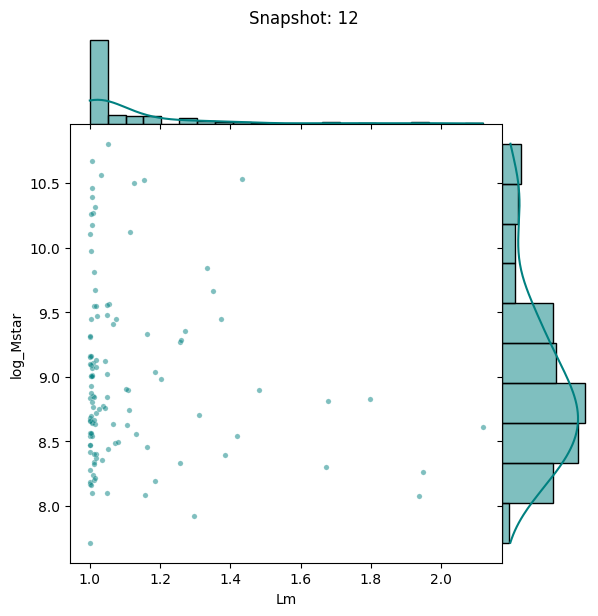

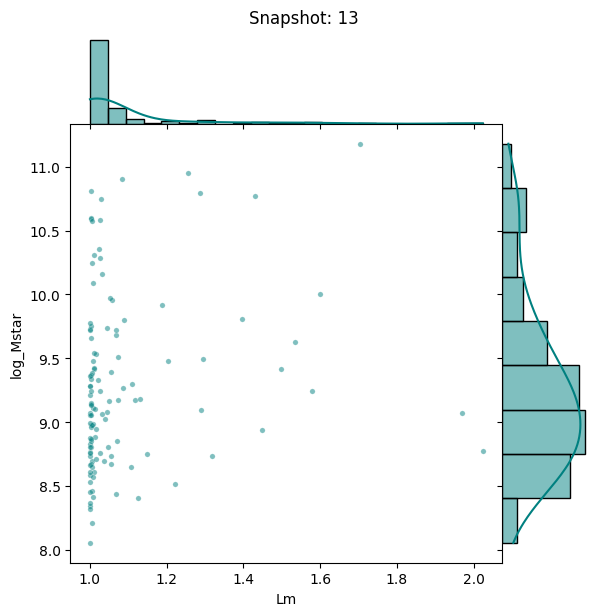

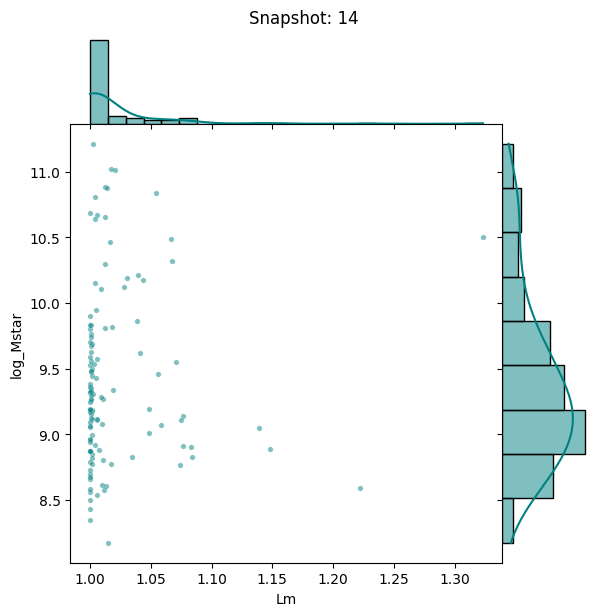

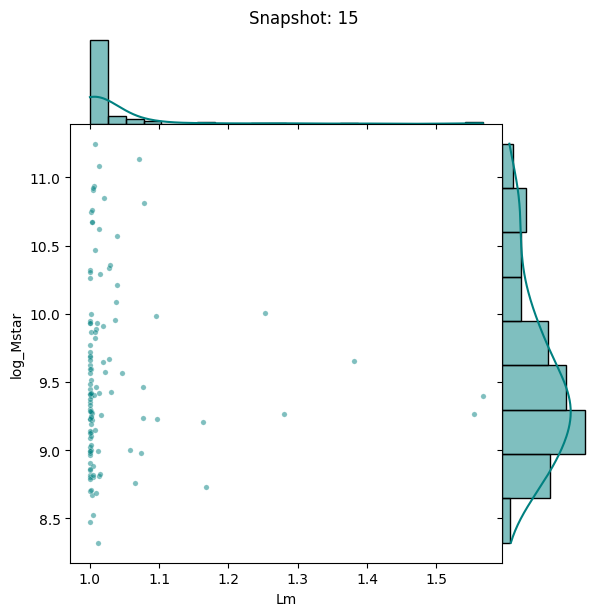

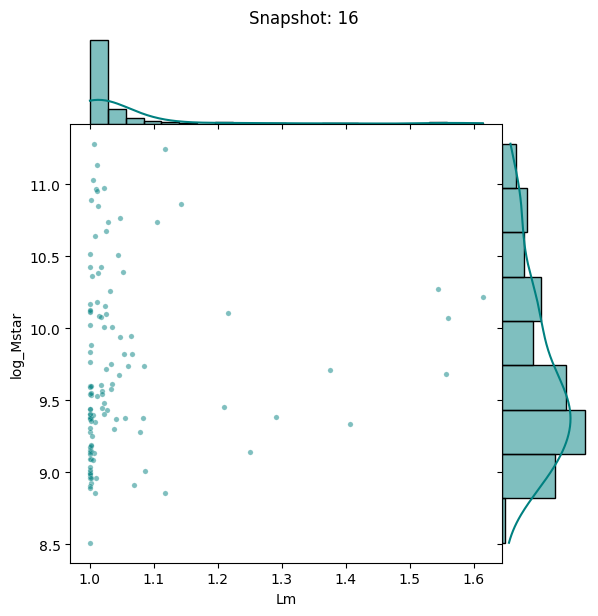

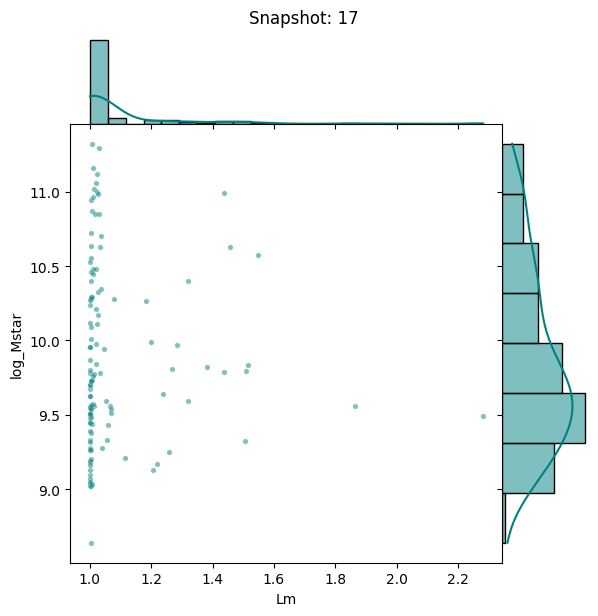

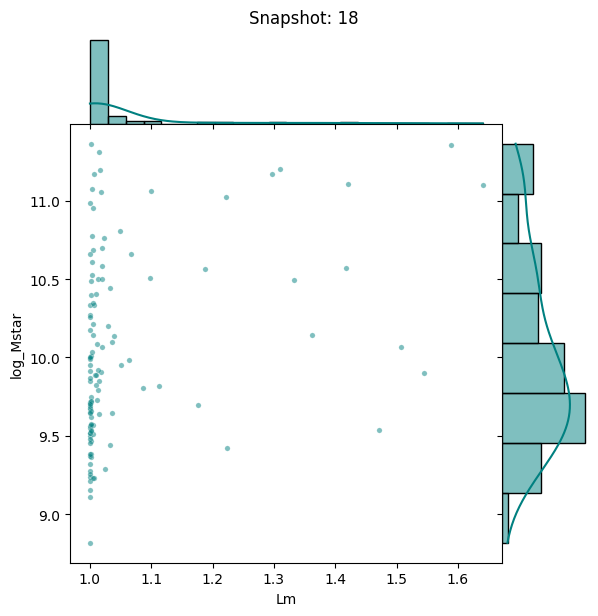

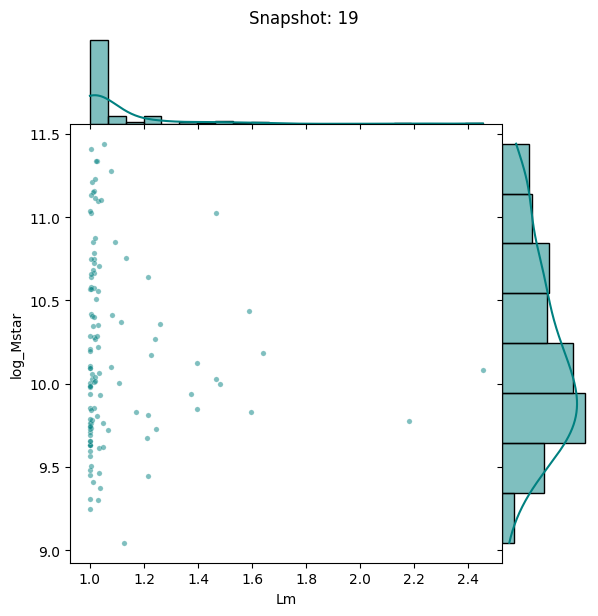

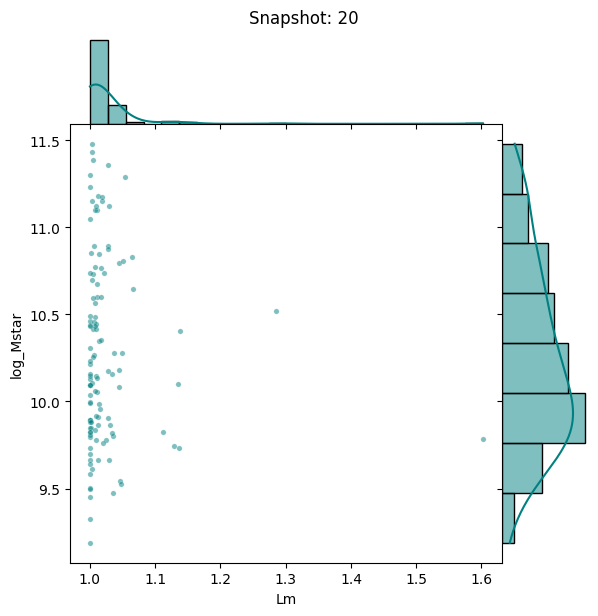

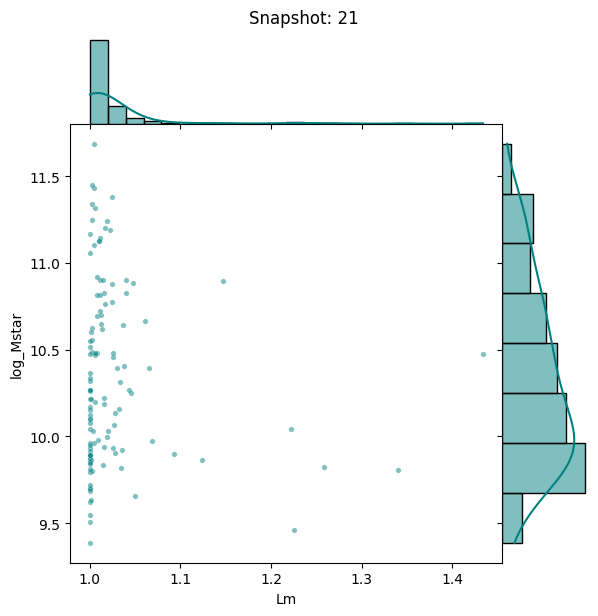

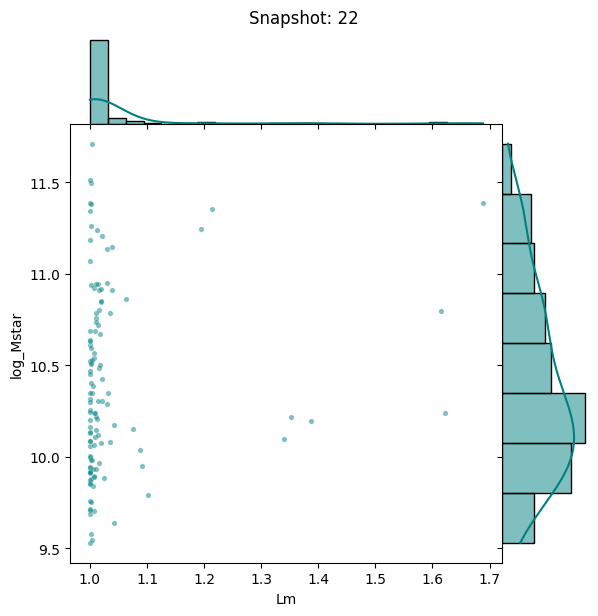

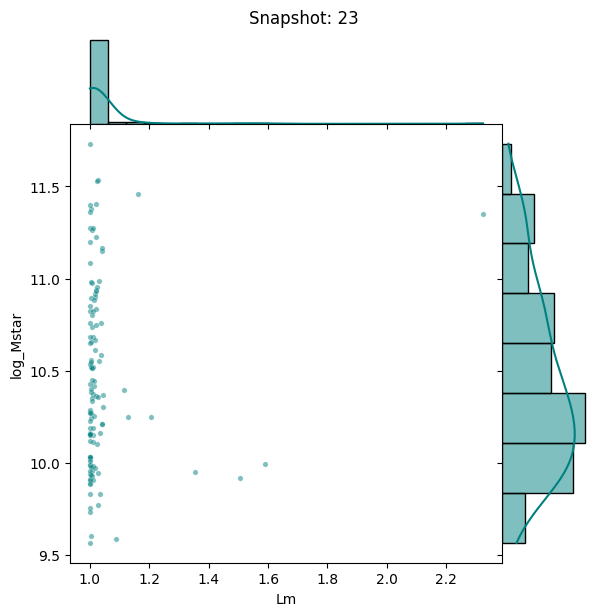

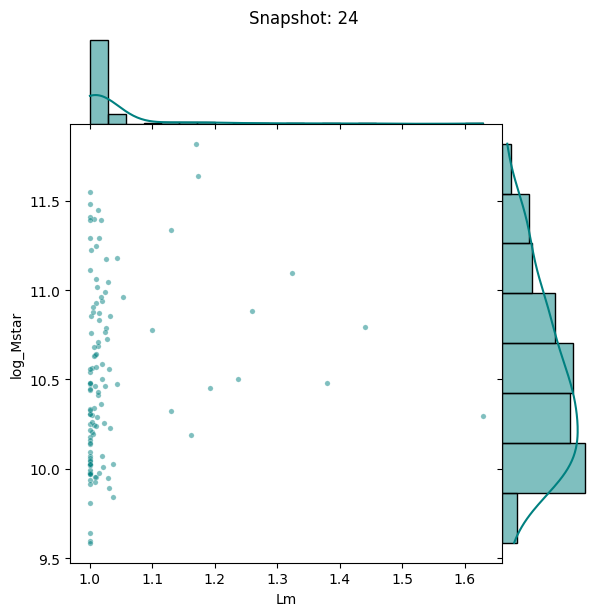

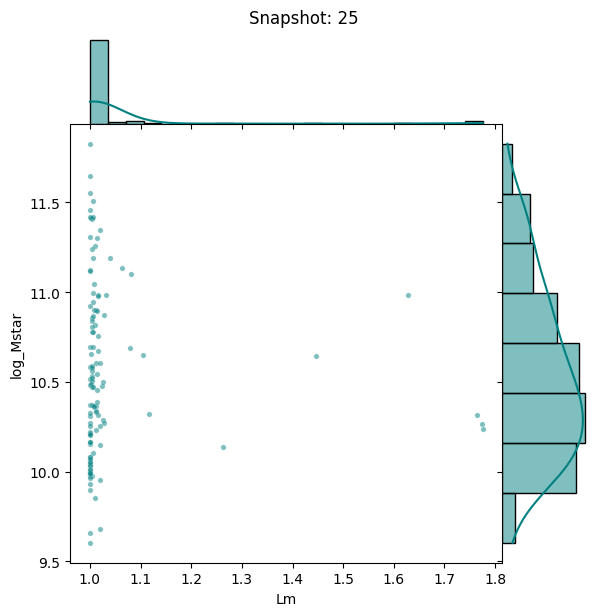

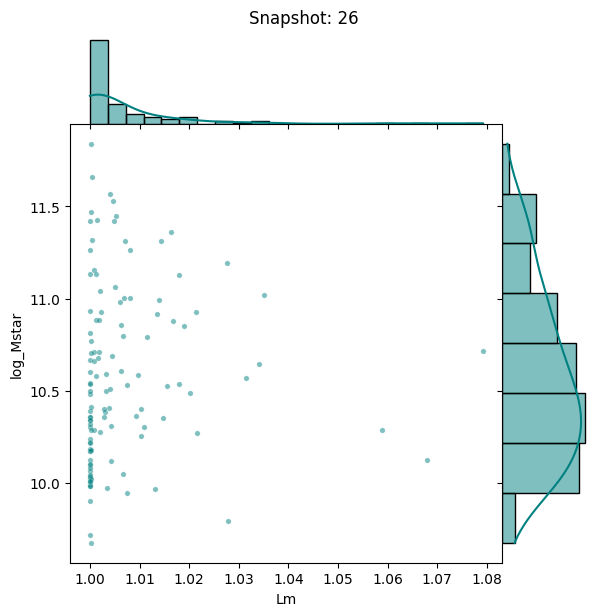

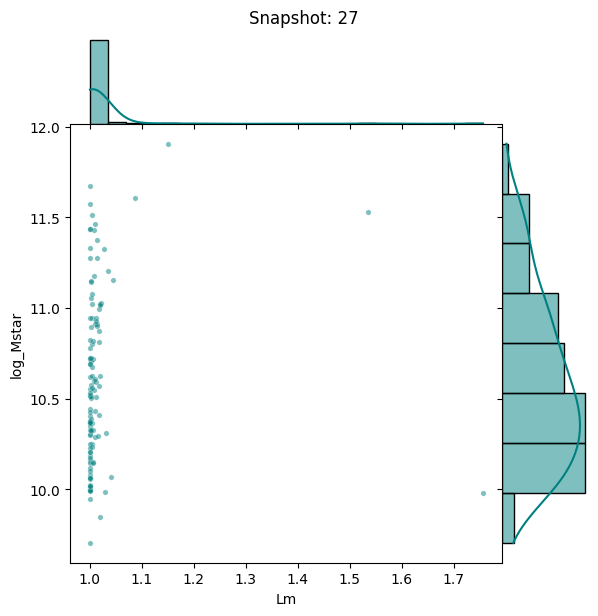

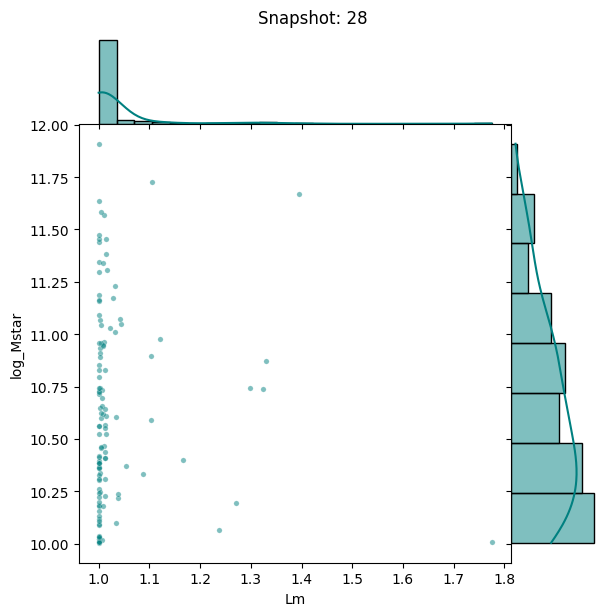

In [14]:
# Gráficos con las galaxias que sufrieron sólo un major merger en su historia
df_final = (
    result_merger_no
    .select([
        pl.col("SnapNum"),
        pl.col("Stars_Mass").log10().alias("log_Mstar"),
        #pl.col("BlackHoleMass").log10().alias("log_MBH"),
        pl.col('12+log(O/H)'),
        pl.col('Lm'),
        #(pl.col('BlackHoleMassAccretionRate')/pl.col('BlackHoleMass')).log10().alias('log_Eddington_Ratio'),
    ])
    .to_pandas() # Aquí debería funcionar si tienes pyarrow
)

# Ejemplo: Mostrar 3 momentos clave en una fila
snaps_to_show = [12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28]
for s in snaps_to_show:
    plot_snap(df_final, s, "Lm", "log_Mstar")
    plt.show()

Lo que queremos calcular ahora es el delta t, es decir separa los registros según antes (dt<0) o después (dt>0) del merger.
La idea es cuantificar cuanto cambian las magnitudes luego del evento.

In [15]:
# Creamos delta snap para cada galaxia, que es la diferencia entre el snap actual y el snap del major merger
# Primero obtenemos el snap del major merger para cada galaxia
major_merger_snaps = (
    result_merger_no
    .filter(pl.col("Lm") > 1.25)
    .group_by("RootGalaxyID")
    .agg(pl.min("SnapNum").alias("Snap_Major_Merger"))
)

# Separamos tambien diferencia temporal
major_merger_time = (
    result_merger_no
    .filter(pl.col("Lm") > 1.25)
    .group_by("RootGalaxyID")
    .agg(pl.min("LookbackTime(Gyr)").alias("Time_Major_Merger"))
)

# Luego unimos esta información con el dataset original para calcular delta snap
result_with_delta_no = result_merger_no.join(major_merger_snaps, on="RootGalaxyID", how="left").with_columns(
    (pl.col("SnapNum") - pl.col("Snap_Major_Merger")).alias("Delta_Snap")
)

# Unimos también la información de tiempo para calcular delta tiempo
result_with_delta_no = result_with_delta_no.join(major_merger_time, on="RootGalaxyID", how="left").with_columns(
    (pl.col("LookbackTime(Gyr)") - pl.col("Time_Major_Merger")).alias("Delta_Time_Gyr")
)


In [16]:
result_with_delta_no

GalaxyID,SnapNum,Redshift,Stars_Mass,Stars_KineticEnergy,Stars_Spin_x,Stars_Spin_y,Stars_Spin_z,SF_Mass,SF_Oxygen,SF_Hydrogen,SF_MassWeightedTemperature,SF_KineticEnergy,SF_ThermalEnergy,SF_TotalEnergy,SF_Spin_x,SF_Spin_y,SF_Spin_z,SubHaloGalaxyID,RootGalaxyID,LookbackTime(Gyr),Lm,Log(Stars_Mass),Stars_Spin_Total,SF_Spin_Total,Total_Spin,12+log(O/H),Snap_Major_Merger,Delta_Snap,Time_Major_Merger,Delta_Time_Gyr
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64
1620608,12,3.016505,4.6549e9,4.7754e13,-110.17007,-113.38382,-1.597729,9.9129e9,0.004171,0.7369519,14096.6045,1.1861e14,2.6294e12,-1.0474e15,-11.874759,-203.96361,-355.9548,1620608,1620592,11.68,1.015702,9.66791,158.100878,410.421715,493.404644,8.548723,23,-11,5.22,6.46
1620607,13,2.478413,8.9888e9,2.2588e14,-179.57306,269.90918,186.75658,1.6828e10,0.004805,0.7333201,19545.84,4.3473e14,6.3381e12,-2.7079e15,-137.959,-132.17921,269.66498,1620607,1620592,11.17,1.058314,9.953704,374.132957,330.489381,572.814799,8.612301,23,-10,5.22,5.95
1620606,14,2.237037,1.4998e10,3.2201e14,-257.9472,83.82947,216.85909,1.8747e10,0.007965,0.7193629,26476.67,3.7830e14,9.6395e12,-3.8851e15,-546.21814,12.207579,289.3705,1620606,1620592,10.87,1.04342,10.176032,347.263593,618.254452,955.077697,8.840132,23,-9,5.22,5.65
1620605,15,2.01241,2.0967e10,4.6505e14,-299.38834,122.41683,257.0124,1.6859e10,0.011262,0.7015376,27409.744,3.6749e14,8.9570e12,-3.6810e15,-598.54156,236.10997,243.31071,1620605,1620592,10.54,1.000304,10.321528,413.127864,687.895354,1088.642635,9.001454,23,-8,5.22,5.32
1620604,16,1.736966,2.6801e10,5.8635e14,-276.64853,223.81375,194.02141,1.5091e10,0.013725,0.684758,19762.441,3.8680e14,5.7172e12,-2.9602e15,-725.20807,723.84174,366.2823,1620604,1620592,10.05,1.000059,10.428158,405.303974,1088.134336,1488.525385,9.097847,23,-7,5.22,4.83
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3261909,24,0.365669,3.7115e10,6.4500e14,-128.613,-416.09872,-142.60973,7.6594e9,0.015012,0.671923,6967.8965,1.4462e14,9.9260e11,-8.8523e14,-114.33254,-2480.9275,-918.8959,3261909,3261905,4.12,1.009758,10.569554,458.2761,2648.101747,3094.927731,9.144992,19,5,7.96,-3.84
3261908,25,0.270901,3.8782e10,6.7243e14,-105.60502,-592.6959,-129.64458,7.6572e9,0.014927,0.6726847,6690.908,1.5501e14,9.2286e11,-8.7239e14,-347.44696,-2548.7957,-1104.567,3261908,3261905,3.24,1.00406,10.588631,615.831606,2799.490519,3405.510798,9.142055,19,6,7.96,-4.72
3261907,26,0.18271,4.0490e10,7.1699e14,-155.21558,-683.6869,-186.05978,6.7869e9,0.01518,0.6713456,6138.736,1.3286e14,7.2205e11,-7.6688e14,-682.9887,-2715.0642,-1032.5027,3261907,3261905,2.32,1.006358,10.607349,725.353635,2983.975369,3706.614354,9.150204,19,7,7.96,-5.64


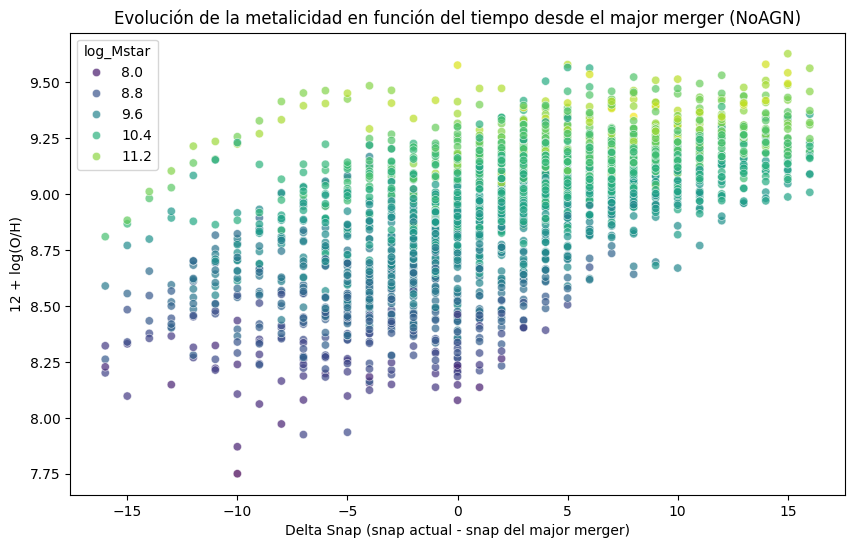

In [35]:
df =result_with_delta_no.with_columns(
    pl.col("Delta_Snap").alias("Delta_Snap"),
    pl.col("Stars_Mass").log10().alias("log_Mstar"),
    pl.col("SnapNum").alias("SnapNum"),
    pl.col("Delta_Time_Gyr").alias("Delta_Time_Gyr"),
    pl.col("Lm").alias("Lm"),
    pl.col("12+log(O/H)").alias("12+log(O/H)")).to_pandas()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Delta_Snap", y="12+log(O/H)", hue="log_Mstar", palette="viridis", alpha=0.7)
plt.title("Evolución de la metalicidad en función del tiempo desde el major merger (NoAGN)")
plt.xlabel("Delta Snap (snap actual - snap del major merger)")
plt.ylabel("12 + log(O/H)")
plt.legend(title="log_Mstar")
plt.show()